# **Fase 2: Auditoría Adversaria a modelos basados en Machine Learning.**

Autor: Daniel Gomollón Embid

Trabajo Fin de Grado: Análisis, Explotación y Mitigación de Vulnerabilidades de Sistemas de Detección de Intrusiones basados en Machine Learning

Fecha: 07/03/2026

**Universidad: Universidad de Zaragoza**

## **Etapa 2: Ingeniería Inversa del Modelo y Trade-off de Sigilo. Rompiendo la lógica del modelo**

En esta fase, dejamos atrás los ataques genéricos de la etapa 1 (FGSM/PGD y SGFP/SIGMA) para desplegar armamento de caja blanca diseñado específicamente para la arquitectura interna de nuestros modelos:

- **ACE (ResNet):** Optimización asimétrica de gradientes con momentum.

- **LEAF (LGBM):** Sinergia global de umbrales + navegación física por raíces.

- **THORN (LGBM):** Navegación de umbrales en nodos raíz de alta varianza.

- **DLA (ResNet):** Colisión latente. Forzamos a la red a "pensar" que un ataque es semánticamente idéntico a un flujo benigno de alta confianza.

Además, introducimos dos métricas críticas de auditoría forense para evaluar la indetectabilidad del ataque:

- **Norma $L_0$**: Promedio de variables modificadas por flujo. Un valor bajo indica alta evasión de sistemas IDS/IPS analíticos.
- **Norma $L_2$**: Magnitud de la energía de la perturbación (Distancia Euclidiana).

El éxito de un ataque en el mundo real se define por la maximización del Attack Success Rate (ASR) sujeto a la minimización de $L_0$ y el cumplimiento estricto del motor físico.

## 1. Inicialización y Carga del Entorno Físico

In [ ]:
import os
import sys
from pathlib import Path

# --- CONFIGURACIÓN DE PROTECCIÓN DE HARDWARE ---
# Forzamos a usar máximo 6 hilos para proteger el Ryzen 7 5800H
os.environ["OMP_NUM_THREADS"] = "8"
os.environ["OPENBLAS_NUM_THREADS"] = "8"
os.environ["MKL_NUM_THREADS"] = "8"

project_root = Path(r"C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental")
sys.path.insert(0, str(project_root))
os.chdir(project_root)

# Importar librerías core
import time
import torch
import numpy as np
import pandas as pd
import polars as pl
import joblib
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
import plotly.graph_objects as go
from tqdm.notebook import tqdm

# Importar nuestros módulos
from src.config import Config
from src.helpers import set_seed
from src.utils.domain_constraints import DomainConstraints

# Ataques
from src.attacks.ace import ACEAttack
from src.attacks.leaf import LEAFAttack
from src.attacks.thorn import THORNAttack
from src.attacks.dla import DLAAttack
from src.attacks.descartados.irg import IRGAttack
from src.attacks.descartados.mirage import MIRAGEAttack

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"[*] Device: {device}")

# 3. Rutas y directorios
DATA_PATH  = project_root / "data" / "processed" / "resultados_2_buffer"
OUTPUT_DIR = project_root / "outputs" / "models" / "lgbm"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CHECKPOINT_DIR = project_root / "outputs" / "checkpoints_ataques"

print(f"[*] Raíz:   {project_root}")
print(f"[*] Datos:  {DATA_PATH}")
print(f"[*] Existe: {DATA_PATH.exists()}")

[*] Device: cpu
[*] Raíz:   C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental
[*] Datos:  C:\Users\Daniel\Desktop\INGENIERÍA INFORMÁTICA\QUINTO AÑO\TFG\Codigo\Codigo_Experimental\data\processed\resultados_2_buffer
[*] Existe: True


## **2. Carga de Datos y Baselines (Notebook 1)**

Restauramos los resultados forenses del escenario realista (Física ON) calculados en el estudio de ablación. PGD y SGFP actuarán como nuestra línea base de comparación (baseline) contra la cual mediremos la superioridad de ACE y LEAF.

In [ ]:
from src.models.wrapper_attacks import load_resnet_for_attack, load_lgbm_for_attack

# rutas
data_path = Config.DATA_PROCESSED_PATH
models_path = Config.MODELS_PATH

print("[-] Cargando datos de test y modelos...")
X_test = np.load(os.path.join(DATA_PATH, "X_test.npy")).astype(np.float32)
y_test = np.load(os.path.join(DATA_PATH, "y_test.npy"))

# 1. Extraer los índices de TODOS los ataques y barajar (Misma semilla)
idx_ataques = np.where(y_test != 0)[0]

# Fijar semilla para reproducibilidad
# Lo ponemos aquí para obtener la misma cantidad de muestras de ataques que en etapa 1
set_seed(Config.SEED)

np.random.shuffle(idx_ataques)

N_MUESTRAS = 2500
idx_ataques = idx_ataques[:N_MUESTRAS]

X_ataques = X_test[idx_ataques]
y_ataques = y_test[idx_ataques]

# 2. Cargar Modelos y Motor Físico
print("[-] Cargando Modelos de IA (TabularResNet y LightGBM)...")
model_wrapped = load_resnet_for_attack(
    device=device,
    input_dim=X_test.shape[1],
    models_path=models_path
)
print("   [✓] ResNetWrapper instanciado.")

lgbm_wrapper = load_lgbm_for_attack(models_path=models_path)

# 3 - Inicializar Motor Físico
print("[-] Inicializando el motor físico (Domain Constraints)...")
dc = DomainConstraints.from_artifacts(models_path=models_path, data_path=data_path)

# 4. FILTRADO ROBUSTO (Igual que en NB1 para igualar dimensiones)
print("[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...")
preds_rn = model_wrapped.predict(X_ataques)
preds_lgbm = lgbm_wrapper.predict(X_ataques)

mask_rn_detectados = (preds_rn != 0)
mask_lgbm_detectados = (preds_lgbm != 0)
mask_robusta = mask_rn_detectados & mask_lgbm_detectados

X_ataques = X_ataques[mask_robusta]
y_ataques = y_ataques[mask_robusta]

print(f"  ↳ Muestras descartadas (Ya evadidas por defecto): {2500 - len(X_ataques)}")
print(f"  ↳ Muestras blindadas a atacar: {len(X_ataques)}")

# 4. Carga de Baselines (Notebook 1)
print("\n[-] Cargando métricas forenses del Estudio de Ablación (Física ON)...")
try:
    # Cargamos todos los artefactos en bloque
    df_ablacion = pd.DataFrame(joblib.load(CHECKPOINT_DIR / "resultados_ablacion.pkl"))
    xadv_por_epsilon = joblib.load(CHECKPOINT_DIR / "xadv_por_epsilon.pkl")
    checkpoints_nb1 = joblib.load(CHECKPOINT_DIR / "resultados_forense.pkl")

    # Extracción de métricas clave
    pgd_baseline_max = checkpoints_nb1["pgd_on"]
    sgfp_baseline_max = checkpoints_nb1["sgfp_on"]
    eps_guardados = list(xadv_por_epsilon["pgd_on"].keys())

    print(f"  [✓] Histórico ASR y Diccionario X_adv cargados. Epsilons en dict: {eps_guardados}")
    print(f"  [✓] Baseline PGD (ResNet) ASR Máximo: {pgd_baseline_max.asr * 100:.2f}%")
    print(f"  [✓] Baseline SGFP (LightGBM) ASR Máximo: {sgfp_baseline_max.asr * 100:.2f}%")
except Exception as e:
    print(f"  [X] Error crítico cargando baselines: {e}")

[-] Cargando datos de test y modelos...
[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).
[-] Cargando Modelos de IA (TabularResNet y LightGBM)...
[-] Instanciando TabularResNet...
[-] Cargando pesos desde outputs\models\best_resnet.pt...
   [✓] ResNetWrapper instanciado.
[-] Cargando modelo LightGBM desde outputs\models\lgbm\lgbm_baseline.pkl...
[-] Inicializando el motor físico (Domain Constraints)...
[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...
  ↳ Muestras descartadas (Ya evadidas por defecto): 795
  ↳ Muestras blindadas a atacar: 1705

[-] Cargando métricas forenses del Estudio de Ablación (Física ON)...
  [✓] Histórico ASR y Diccionario X_adv cargados. Epsilons en dict: [2.0]
  [✓] Baseline PGD (ResNet) ASR Máximo: 56.13%
  [✓] Baseline SGFP (LightGBM) ASR Máximo: 8.45%


In [ ]:
print("[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...")

# Predicciones originales (sin ataque)
preds_rn = model_wrapped.predict(X_ataques)
preds_lgbm = lgbm_wrapper.predict(X_ataques)

# Mascaras de muestras que fueron DETECTADAS correctamente como Ataque (clase != 0)
mask_rn_detectados = (preds_rn != 0)
mask_lgbm_detectados = (preds_lgbm != 0)

# Para ser totalmente justos en la comparativa, nos quedamos con las muestras
# que AMBOS modelos fueron capaces de detectar originalmente.
mask_robusta = mask_rn_detectados & mask_lgbm_detectados

X_ataques = X_ataques[mask_robusta]
y_ataques = y_ataques[mask_robusta]

print(f"  ↳ Muestras descartadas (Ya evadidas por defecto): {N_MUESTRAS - len(X_ataques)}")
print(f"  ↳ Muestras blindadas a atacar: {len(X_ataques)}")

[-] Filtrando muestras (Evaluando solo los verdaderos positivos)...
  ↳ Muestras descartadas (Ya evadidas por defecto): 795
  ↳ Muestras blindadas a atacar: 1705


## **3. Funciones de Auditoría Forense ($L_0$ y $L_2$)**

Definimos el evaluador de sigilo. Dado que operamos en el espacio escalado (por el QuantileTransformer de nuestro pipeline), las mediciones de $L_2$ representan perturbaciones normalizadas, mientras que $L_0$ es invariante a la escala e indica estrictamente la dimensionalidad del ataque.

Matemáticamente:$$L_0 = \frac{1}{N}\sum_{i=1}^{N} \sum_{j=1}^{M} \mathbb{I}(x_{ij} \neq x_{adv, ij})$$

In [ ]:
def evaluar_sigilo(X_orig, X_adv, umbral_tolerancia=1e-5):
    """
    Calcula L0 y L2 ignorando las diferencias microscópicas debidas
    a la inestabilidad de coma flotante (1e-5).
    """
    # [CHECK DE RIGUROSIDAD ACADÉMICA]
    # Garantizar que evaluamos en espacio normalizado para que L2 tenga sentido matemático.
    if X_orig.max() > 5.5 or X_adv.max() > 5.5: # 5.5 por el límite del QuantileTransformer
        print("[!] ADVERTENCIA: Se están pasando datos CRUDOS a evaluar_sigilo. L2 será inválido.")

    diff = np.abs(X_orig - X_adv)

    # L0: Contar características donde la diferencia es real
    mutaciones = diff > umbral_tolerancia
    L0_mean = np.sum(mutaciones, axis=1).mean()

    # L2: Norma euclidiana por muestra
    L2_mean = np.linalg.norm(diff, axis=1).mean()

    return round(L0_mean, 2), round(L2_mean, 4)

def evaluar_ataque_obj(res_obj, nombre, modelo_nombre):
    """Función auxiliar para empaquetar resultados."""
    l0, l2 = evaluar_sigilo(X_ataques, res_obj.X_adv)
    return {"Modelo": modelo_nombre, "Ataque": nombre, "ASR (%)": res_obj.asr*100, "L0 (Vars)": l0, "L2 (Energía)": l2}

# Evaluamos los baselines
l0_pgd, l2_pgd = evaluar_sigilo(X_ataques, pgd_baseline_max.X_adv)
l0_sgfp, l2_sgfp = evaluar_sigilo(X_ataques, sgfp_baseline_max.X_adv)

print("--- DIAGNÓSTICO DE SIGILO BASELINE ---")
print(f"PGD  (Física ON) -> Modifica en media {l0_pgd} variables. Energía (L2): {l2_pgd}")
print(f"SGFP (Física ON) -> Modifica en media {l0_sgfp} variables. Energía (L2): {l2_sgfp}")

--- DIAGNÓSTICO DE SIGILO BASELINE ---
PGD  (Física ON) -> Modifica en media 26.56 variables. Energía (L2): 14.577799797058105
SGFP (Física ON) -> Modifica en media 19.15 variables. Energía (L2): 1.6687999963760376


### Diagnóstico de Sigilo Baseline...

- PGD: Modificar **26.56** variables de media (de un total de unas 66 que tiene tu dataset) significa que el ataque está alterando casi el 40% de las características del flujo de red. Además, una energía ($L_2$) de **14.58** es altísima. En un entorno real, cualquier motor de detección de anomalías estadísticas (incluso uno simple sin IA) haría saltar las alarmas al ver un flujo tan radicalmente mutado.

- SGFP: Al estar guiado por SHAP, es más selectivo y modifica menos variables (**19.15**) con muchísima menos energía (**1.67**). Aún así, tocar casi 20 variables de un paquete o flujo de red sigue siendo un rastro forense muy evidente.

## **4. Ejecución de Ataques sobre TabularResNet (ACE & DLA)**

En redes neuronales, el sigilo es más difícil de conseguir debido a la naturaleza continua del gradiente. ACE intenta mitigarlo mediante máscaras, mientras que DLA busca la invisibilidad semántica.

Guía del ataque provisional:

* **Gradient Masking Asimétrico:** El ataque solo se permite fluir a través del subespacio de características *Forward* (modificables), evitando desperdiciar presupuesto de perturbación en variables inmutables.
* **Momentum Iterativo ($\mu=0.4$):** Acumula la inercia de los gradientes de pasos anteriores para "saltar" mínimos locales y rugosidades del espacio tabular, muy comunes debido a las transformaciones de cuantiles.
* **Step Size Adaptativo ($\alpha = \epsilon/5$):** Permite una convergencia rápida hacia la frontera de decisión en pocas iteraciones.

Evaluaremos ACE en todo el espectro de $\epsilon$ para medir cómo evoluciona su sigilo ($L_0$) frente a su capacidad de evasión.

In [ ]:
set_seed()  # Asegurar reproducibilidad en la selección de anclas
# Test rápido sobre 200 muestras
for steps in [20, 40, 60, 80, 100]:
    atk_test = ACEAttack(
        constraints    = dc,
        epsilon        = 2.0,
        alpha          = 2.0 / 5.0,
        steps          = steps,
        momentum       = 0.0,
        random_start   = True,
        adaptive_alpha = True,
        device         = device,
    )
    atk_test.verbose = False
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], model_wrapped)
    print(f"steps={steps:>2} → ASR: {res_test.asr*100:.2f}%")

[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).
steps=20 → ASR: 52.00%
steps=40 → ASR: 54.00%
steps=60 → ASR: 49.00%
steps=80 → ASR: 49.50%
steps=100 → ASR: 44.50%


In [ ]:
# Estudio 1: latent_weight (balance MSE latente vs CE clasificación)
set_seed()  # Asegurar reproducibilidad en la selección de anclas
# Actualmente usamos 0.1 — puede que más peso en CE mejore el ASR
# === PREPARACIÓN PARA DLA ===
X_benign_pool = X_test[y_test == 0]
probs_benign = model_wrapped.predict_proba(X_benign_pool)
top_idx = np.argsort(probs_benign[:, 0])[-50:]
X_anchors = X_benign_pool[top_idx]

resnet_pytorch = model_wrapped.model if hasattr(model_wrapped, 'model') else model_wrapped
target_layer = list(resnet_pytorch.children())[-2]

print("=== DLA: Sweep de latent_weight ===")
for lw in [0.0, 0.1, 0.2, 0.3, 0.5, 0.7, 1.0]:
    atk_test = DLAAttack(
        constraints    = dc,
        target_layer   = target_layer,
        X_anchors      = X_anchors,
        extraction_mode= 'grey_box',
        epsilon        = 2.0,
        alpha          = 2.0 / 5.0,
        steps          = 40,
        momentum       = 0.4,
        latent_weight  = lw,
        device         = device,
    )
    atk_test.verbose = False
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], model_wrapped)
    print(f"latent_weight={lw:.1f} → ASR: {res_test.asr*100:.2f}%")

[-] Semilla global fijada en 42 (Reproducibilidad Garantizada).
=== DLA: Sweep de latent_weight ===
latent_weight=0.0 → ASR: 64.00%
latent_weight=0.1 → ASR: 64.00%
latent_weight=0.2 → ASR: 64.00%
latent_weight=0.3 → ASR: 63.50%
latent_weight=0.5 → ASR: 63.00%
latent_weight=0.7 → ASR: 63.50%
latent_weight=1.0 → ASR: 59.00%


In [ ]:
# Estudio 2: tamaño del anchor pool
# Más anclas = mejor nearest-anchor assignment
print("\n=== DLA: Sweep de anchor pool size ===")
idx_benignos  = np.where(y_test == 0)[0]
X_benignos_sc = X_test[idx_benignos]
probs_benign  = model_wrapped.predict_proba(X_benignos_sc[:2000])

for n_anchors in [1, 5, 10, 25, 50, 100, 500]:
    top_idx   = np.argsort(probs_benign[:, 0])[-n_anchors:]
    X_anchors_test = X_benignos_sc[top_idx]

    atk_test = DLAAttack(
        constraints    = dc,
        target_layer   = target_layer,
        X_anchors      = X_anchors_test,
        extraction_mode= 'grey_box',
        epsilon        = 2.0,
        alpha          = 2.0 / 5.0,
        steps          = 40,
        momentum       = 0.4,
        latent_weight  = 0.5,
        device         = device,
    )
    atk_test.verbose = False
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], model_wrapped)
    print(f"n_anchors={n_anchors:>3} → ASR: {res_test.asr*100:.2f}%")


=== DLA: Sweep de anchor pool size ===
n_anchors=  1 → ASR: 62.50%
n_anchors=  5 → ASR: 62.00%
n_anchors= 10 → ASR: 62.00%
n_anchors= 25 → ASR: 62.50%
n_anchors= 50 → ASR: 62.50%
n_anchors=100 → ASR: 63.00%
n_anchors=500 → ASR: 62.50%


In [ ]:
# Estudio 3: steps (ya tienes datos de ACE, replicar para DLA)
print("\n=== DLA: Sweep de steps ===")
for steps in [20, 40, 60, 80, 100]:
    atk_test = DLAAttack(
        constraints    = dc,
        target_layer   = target_layer,
        X_anchors      = X_anchors,
        extraction_mode= 'grey_box',
        epsilon        = 2.0,
        alpha          = 2.0 / steps * 2,  # alpha adaptativo al número de steps
        steps          = steps,
        momentum       = 0.4,
        latent_weight  = 0.5,
        device         = device,
    )
    atk_test.verbose = False
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], model_wrapped)
    print(f"steps={steps:>3} → ASR: {res_test.asr*100:.2f}%")


=== DLA: Sweep de steps ===
steps= 20 → ASR: 47.00%
steps= 40 → ASR: 13.50%
steps= 60 → ASR: 12.00%
steps= 80 → ASR: 7.00%
steps=100 → ASR: 5.00%


In [ ]:
# Estudio 4: momentum
print("\n=== DLA: Sweep de momentums ===")
for momentums in [0.0, 0.1, 0.4, 0.7, 0.9]:
    atk_test = DLAAttack(
        constraints    = dc,
        target_layer   = target_layer,
        X_anchors      = X_anchors,
        extraction_mode= 'grey_box',
        epsilon        = 2.0,
        alpha          = 2.0 / 5.0 * 2,  # alpha adaptativo al número de steps
        steps          = 40,
        momentum       = momentums,
        latent_weight  = 0.5,
        device         = device,
    )
    atk_test.verbose = False
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], model_wrapped)
    print(f"momentum={momentums} → ASR: {res_test.asr*100:.2f}%")


=== DLA: Sweep de momentums ===
momentum=0.0 → ASR: 65.50%
momentum=0.1 → ASR: 65.50%
momentum=0.4 → ASR: 64.00%
momentum=0.7 → ASR: 64.00%
momentum=0.9 → ASR: 63.50%


In [ ]:
import time
from IPython.display import display, Markdown
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

# Asegúrate de que los nombres de los archivos coincidan con tu estructura
from src.attacks.ace import ACEAttack
from src.attacks.dla import DLAAttack

# --- Función de Barras de Progreso ---
def ejecutar_con_barra(ataque, X, y, modelo, nombre_ataque, color_barra):
    ataque.verbose = False
    chunk_size = 100
    evasiones_totales = 0
    X_adv_lista = []
    ultimo_res = None

    for i in tqdm(range(0, len(X), chunk_size), desc=f"   {nombre_ataque}", leave=False, colour=color_barra):
        end = min(i + chunk_size, len(X))
        res_chunk = ataque.run(X[i:end], y[i:end], modelo)
        evasiones_totales += int(np.round(res_chunk.asr * len(X[i:end])))
        X_adv_lista.append(res_chunk.X_adv)
        ultimo_res = res_chunk

    asr_total = evasiones_totales / len(X)
    X_adv_total = np.vstack(X_adv_lista)
    ultimo_res.asr = asr_total
    ultimo_res.X_adv = X_adv_total
    return asr_total, ultimo_res

print(f"[>>] LANZANDO COMPARATIVA FINAL: ACE (Optimizado) vs DLA (Grey-Box)")
print("="*100)

# === PREPARACIÓN PARA DLA ===
X_benign_pool = X_test[y_test == 0]
probs_benign = model_wrapped.predict_proba(X_benign_pool)
top_idx = np.argsort(probs_benign[:, 0])[-50:]
X_anchors = X_benign_pool[top_idx]

resnet_pytorch = model_wrapped.model if hasattr(model_wrapped, 'model') else model_wrapped
target_layer = list(resnet_pytorch.children())[-2]

print(f"[*] Configuración: ACE (μ=0.0) | DLA (Grey-Box Hooks)")
print("-" * 80)

epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]
resultados_resnet = []

for eps in epsilons:
    print(f"\nEvaluando Epsilon = {eps:.2f}")
    print("-" * 80)

    linea_id = f"resnet_{eps}"
    linea_progreso = display(Markdown(
        f"  ↳ **ACE (Opt)**: --- | **DLA (GB)**: --- | **PGD Base**: --- "
    ), display_id=linea_id)

    # Baseline PGD
    try:
        mask = (df_ablacion['Ataque'].str.contains('PGD')) & \
               (df_ablacion['Epsilon'] == eps) & \
               (df_ablacion['Escenario'].str.contains('ON'))
        asr_pgd_base = df_ablacion[mask]['ASR (%)'].values[0]
    except:
        asr_pgd_base = 0.0

    # 1. ACE OPTIMIZADO (Sin momentum para evitar overshooting)
    atk_ace = ACEAttack(
        constraints=dc, epsilon=eps, alpha=eps/5.0, steps=40,
        momentum=0.0, # valores según los estudios anteriores
        random_start=True, adaptive_alpha=True, device=device
    )
    start_t = time.time()
    asr_ace, res_ace = ejecutar_con_barra(atk_ace, X_ataques, y_ataques, model_wrapped, f"ACE ε={eps}", "dodgerblue")
    t_ace = time.time() - start_t
    l0_ace, l2_ace = evaluar_sigilo(X_ataques, res_ace.X_adv)

    resultados_resnet.append({
        "Epsilon": eps, "Ataque": "ACE (Optimizado μ=0)", "Modelo": "TabularResNet",
        "ASR (%)": asr_ace * 100, "L0 (Vars)": l0_ace, "L2 (Energía)": l2_ace, "Tiempo": t_ace
    })

    linea_progreso.update(Markdown(
        f"  ↳ **ACE (Opt)**: {asr_ace*100:5.2f}% | **DLA (GB)**: --- | PGD: {asr_pgd_base:5.2f}%"
    ))

    # 2. DLA GREY-BOX (Secuestro Latente)
    atk_dla_gb = DLAAttack(
        constraints=dc, target_layer=target_layer, X_anchors=X_anchors,
        extraction_mode='grey_box', epsilon=eps, alpha=eps/5.0, steps=20,
        latent_weight=0.5, device=device
    )
    start_t = time.time()
    asr_dla_gb, res_dla_gb = ejecutar_con_barra(atk_dla_gb, X_ataques, y_ataques, model_wrapped, f"DLA ε={eps}", "mediumseagreen")
    t_dla_gb = time.time() - start_t
    l0_dla_gb, l2_dla_gb = evaluar_sigilo(X_ataques, res_dla_gb.X_adv)

    resultados_resnet.append({
        "Epsilon": eps, "Ataque": "DLA (Grey-Box)", "Modelo": "TabularResNet",
        "ASR (%)": asr_dla_gb * 100, "L0 (Vars)": l0_dla_gb, "L2 (Energía)": l2_dla_gb, "Tiempo": t_dla_gb
    })

    linea_progreso.update(Markdown(
        f"  ↳ **ACE (Opt)**: {asr_ace*100:5.2f}% | **DLA (GB)**: {asr_dla_gb*100:5.2f}% | PGD: {asr_pgd_base:5.2f}%"
    ))

# Resultados finales
print("\n\nTABLA DE RESULTADOS FINAL (REDES NEURONALES):")
df_resnet_study = pd.DataFrame(resultados_resnet)
display(df_resnet_study.round(3))

[>>] LANZANDO COMPARATIVA FINAL: ACE (Optimizado) vs DLA (Grey-Box)
[*] Configuración: ACE (μ=0.0) | DLA (Grey-Box Hooks)
--------------------------------------------------------------------------------

Evaluando Epsilon = 0.05
--------------------------------------------------------------------------------


  ↳ **ACE (Opt)**:  0.29% | **DLA (GB)**:  0.29% | PGD:  0.29%

   ACE ε=0.05:   0%|          | 0/18 [00:00<?, ?it/s]

   DLA ε=0.05:   0%|          | 0/18 [00:00<?, ?it/s]


Evaluando Epsilon = 0.10
--------------------------------------------------------------------------------


...

  ↳ **ACE (Opt)**: 52.73% | **DLA (GB)**: 69.74% | PGD: 56.13%

   ACE ε=2.0:   0%|          | 0/18 [00:00<?, ?it/s]

   DLA ε=2.0:   0%|          | 0/18 [00:00<?, ?it/s]



TABLA DE RESULTADOS FINAL (REDES NEURONALES):


,Epsilon,Ataque,Modelo,ASR (%),L0 (Vars),L2 (Energía),Tiempo
0,0.05,ACE (Optimizado μ=0),TabularResNet,0.293,19.74,0.251,63.284
1,0.05,DLA (Grey-Box),TabularResNet,0.293,19.72,0.299,19.593
2,0.10,ACE (Optimizado μ=0),TabularResNet,0.411,20.09,0.439,63.163
3,0.10,DLA (Grey-Box),TabularResNet,0.352,19.78,0.416,19.257
4,0.15,ACE (Optimizado μ=0),TabularResNet,0.235,19.67,0.362,63.881
5,0.15,DLA (Grey-Box),TabularResNet,0.352,19.79,0.482,19.654
6,0.30,ACE (Optimizado μ=0),TabularResNet,1.408,22.72,2.724,66.150
7,0.30,DLA (Grey-Box),TabularResNet,1.525,23.35,3.706,19.648
8,0.50,ACE (Optimizado μ=0),TabularResNet,3.109,24.26,4.864,65.322
9,0.50,DLA (Grey-Box),TabularResNet,2.698,24.15,5.578,19.489


## 4.2 Estudio de Sensibilidad: El Problema del Momentum en Espacios Tabulares (Overshooting)
En los resultados anteriores, observamos una anomalía contraintuitiva: al máximo presupuesto ($\epsilon=2.0$), ACE con $\mu=0.9$ (estándar en visión por computador) obtiene un ASR inferior al PGD clásico, a pesar de usar enmascaramiento asimétrico.

Nuestra hipótesis es que, en un espacio tabular altamente restringido por **DomainConstraints**, una inercia alta provoca *overshooting* (sobreimpulso). El gradiente acumula tanta "velocidad" que el ataque se pasa de largo en los mínimos locales estrechos y choca repetidamente contra las fronteras de las variables inmutables, perdiendo eficacia.

Para demostrarlo empíricamente, fijamos el presupuesto en $\epsilon=2.0$ y realizamos un barrido del factor de momentum ($\mu$). Si nuestra hipótesis es correcta:
1. Al acercarnos a $\mu=0.0$, el ASR debería igualar o superar a PGD (demostrando el valor puro del *Gradient Masking*).
2. Deberíamos encontrar un "punto dulce" de inercia ($\mu \approx 0.2 - 0.4$) óptimo para redes tabulares.

[>>] ESTUDIO DE SENSIBILIDAD: IMPACTO DEL MOMENTUM (μ) EN ACE

[!] Evaluando Presupuesto Epsilon = 0.30
--------------------------------------------------
 ↳ ACE (μ=0.0) | ASR:  1.70% | L0: 24.26 | L2: 4.22 | T: 9.4s
 ↳ ACE (μ=0.2) | ASR:  1.35% | L0: 24.29 | L2: 4.25 | T: 9.3s
 ↳ ACE (μ=0.4) | ASR:  0.94% | L0: 24.25 | L2: 3.92 | T: 9.0s
 ↳ ACE (μ=0.5) | ASR:  1.47% | L0: 24.24 | L2: 4.03 | T: 9.0s
 ↳ ACE (μ=0.6) | ASR:  1.29% | L0: 24.27 | L2: 4.15 | T: 9.1s
 ↳ ACE (μ=0.8) | ASR:  1.41% | L0: 23.78 | L2: 3.67 | T: 9.1s
 ↳ ACE (μ=0.9) | ASR:  1.64% | L0: 24.28 | L2: 4.24 | T: 9.1s

[!] Evaluando Presupuesto Epsilon = 0.50
--------------------------------------------------
 ↳ ACE (μ=0.0) | ASR:  2.70% | L0: 24.58 | L2: 5.26 | T: 9.3s
 ↳ ACE (μ=0.2) | ASR:  2.76% | L0: 24.53 | L2: 5.40 | T: 8.9s
 ↳ ACE (μ=0.4) | ASR:  3.11% | L0: 24.54 | L2: 5.40 | T: 9.2s
 ↳ ACE (μ=0.5) | ASR:  2.40% | L0: 24.53 | L2: 5.47 | T: 9.3s
 ↳ ACE (μ=0.6) | ASR:  2.82% | L0: 24.55 | L2: 5.48 | T: 9.3s
 ↳ ACE (

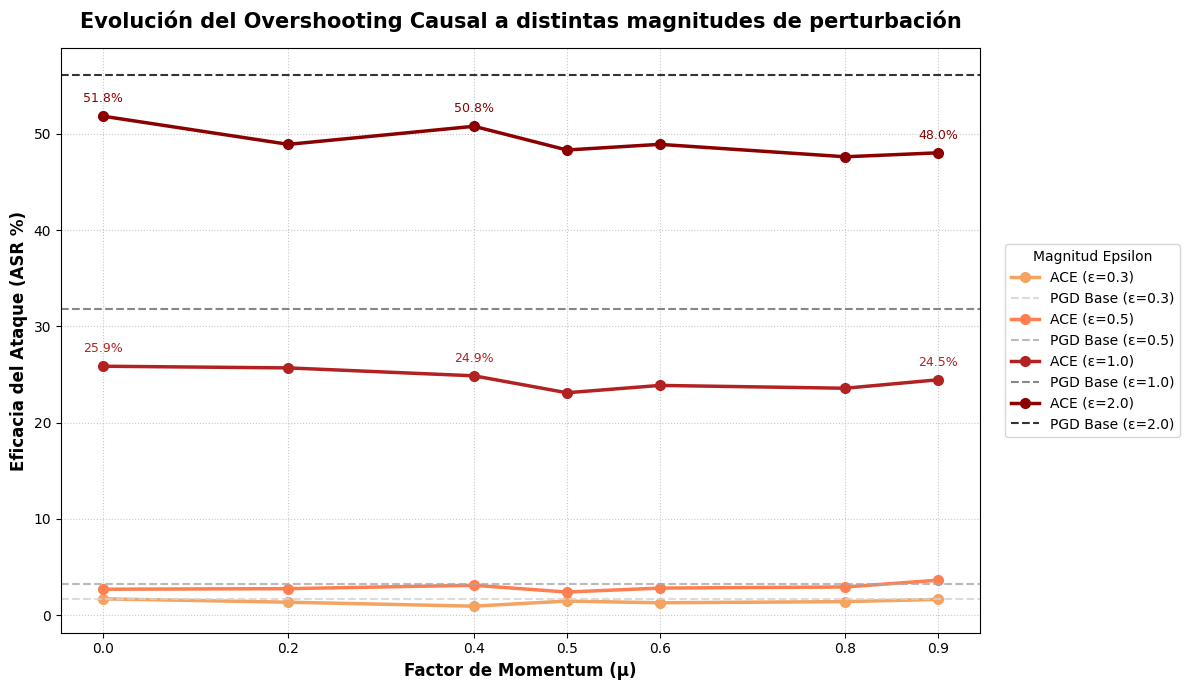

In [ ]:
import time
from IPython.display import display, Markdown
import matplotlib.pyplot as plt
import pandas as pd

print("[>>] ESTUDIO DE SENSIBILIDAD: IMPACTO DEL MOMENTUM (μ) EN ACE")
print("="*80)

# La selección óptima de la evolución de energía
epsilons_eval = [0.3, 0.5, 1.0, 2.0]
valores_mu = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
resultados_mu = []

# --- CORRECCIÓN: Diccionarios de colores para los 4 epsilons ---
colores_ace = {0.3: 'sandybrown', 0.5: 'coral', 1.0: 'firebrick', 2.0: 'darkred'}
colores_pgd = {0.3: 'lightgray', 0.5: 'darkgray', 1.0: 'dimgray', 2.0: 'black'}

for eps_fijo in epsilons_eval:
    print(f"\n[!] Evaluando Presupuesto Epsilon = {eps_fijo:.2f}")
    print("-" * 50)

    # Extraemos el ASR de PGD para el baseline correspondiente
    try:
        asr_pgd_base = df_ablacion[
            (df_ablacion['Ataque'].str.contains('PGD')) &
            (df_ablacion['Epsilon'] == eps_fijo) &
            (df_ablacion['Escenario'].str.contains('ON'))
        ]['ASR (%)'].values[0]
    except:
        # Fallbacks basados en tus ejecuciones anteriores
        fallbacks = {0.3: 1.70, 0.5: 3.28, 1.0: 31.79, 2.0: 56.13}
        asr_pgd_base = fallbacks.get(eps_fijo, 0.0)

    for mu_val in valores_mu:
        atk_ace_mu = ACEAttack(
            constraints=dc,
            epsilon=eps_fijo,
            alpha=eps_fijo/5.0,
            steps=20,
            momentum=mu_val,
            random_start=True,
            adaptive_alpha=True,
            device=device
        )

        atk_ace_mu.verbose = False

        start_t = time.time()
        res_ace_mu = atk_ace_mu.run(X_ataques, y_ataques, model_wrapped)
        duracion = time.time() - start_t

        l0_mu, l2_mu = evaluar_sigilo(X_ataques, res_ace_mu.X_adv)
        asr_mu = res_ace_mu.asr * 100

        resultados_mu.append({
            "Epsilon": eps_fijo,
            "Momentum (μ)": mu_val,
            "ASR (%)": asr_mu,
            "L0 (Vars)": l0_mu,
            "L2 (Energía)": l2_mu,
            "Tiempo (s)": duracion
        })

        # Historial persistente en pantalla (no se borra)
        print(f" ↳ ACE (μ={mu_val:.1f}) | ASR: {asr_mu:5.2f}% | L0: {l0_mu:.2f} | L2: {l2_mu:.2f} | T: {duracion:.1f}s")

df_mu_study = pd.DataFrame(resultados_mu)

# --- VISUALIZACIÓN DEL ESTUDIO A 4 BANDAS ---
plt.figure(figsize=(12, 7))

for eps_fijo in epsilons_eval:
    df_filtrado = df_mu_study[df_mu_study["Epsilon"] == eps_fijo]

    # Curva de ACE
    plt.plot(df_filtrado["Momentum (μ)"], df_filtrado["ASR (%)"],
             marker='o', color=colores_ace[eps_fijo], linewidth=2.5, markersize=7,
             label=f'ACE (ε={eps_fijo})')

    # Baseline de PGD (Línea punteada suave)
    fallbacks = {0.3: 1.70, 0.5: 3.28, 1.0: 31.79, 2.0: 56.13}
    baseline_val = df_ablacion[(df_ablacion['Ataque'].str.contains('PGD')) & (df_ablacion['Epsilon'] == eps_fijo) & (df_ablacion['Escenario'].str.contains('ON'))]['ASR (%)'].values[0] if 'df_ablacion' in locals() else fallbacks[eps_fijo]

    plt.axhline(y=baseline_val, color=colores_pgd[eps_fijo], linestyle='--', linewidth=1.5, alpha=0.8,
                label=f'PGD Base (ε={eps_fijo})')

    # Anotaciones (Solo para 1.0 y 2.0 para no saturar los valores bajos)
    if eps_fijo in [1.0, 2.0]:
        for i, row in df_filtrado.reset_index().iterrows():
            if row["Momentum (μ)"] in [0.0, 0.4, 0.9]:
                plt.annotate(f"{row['ASR (%)']:.1f}%",
                             (row["Momentum (μ)"], row["ASR (%)"]),
                             textcoords="offset points", xytext=(0,10), ha='center', fontsize=9, color=colores_ace[eps_fijo])

plt.title("Evolución del Overshooting Causal a distintas magnitudes de perturbación", fontsize=15, fontweight='bold', pad=15)
plt.xlabel("Factor de Momentum (μ)", fontsize=12, fontweight='bold')
plt.ylabel("Eficacia del Ataque (ASR %)", fontsize=12, fontweight='bold')
plt.xticks(valores_mu)
plt.grid(True, linestyle=':', alpha=0.7)

# Leyenda unificada fuera de la gráfica
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys(), loc='center left', bbox_to_anchor=(1.02, 0.5), title="Magnitud Epsilon")

plt.tight_layout()
plt.show()

[*] Generando gráficas desde los datos en memoria...


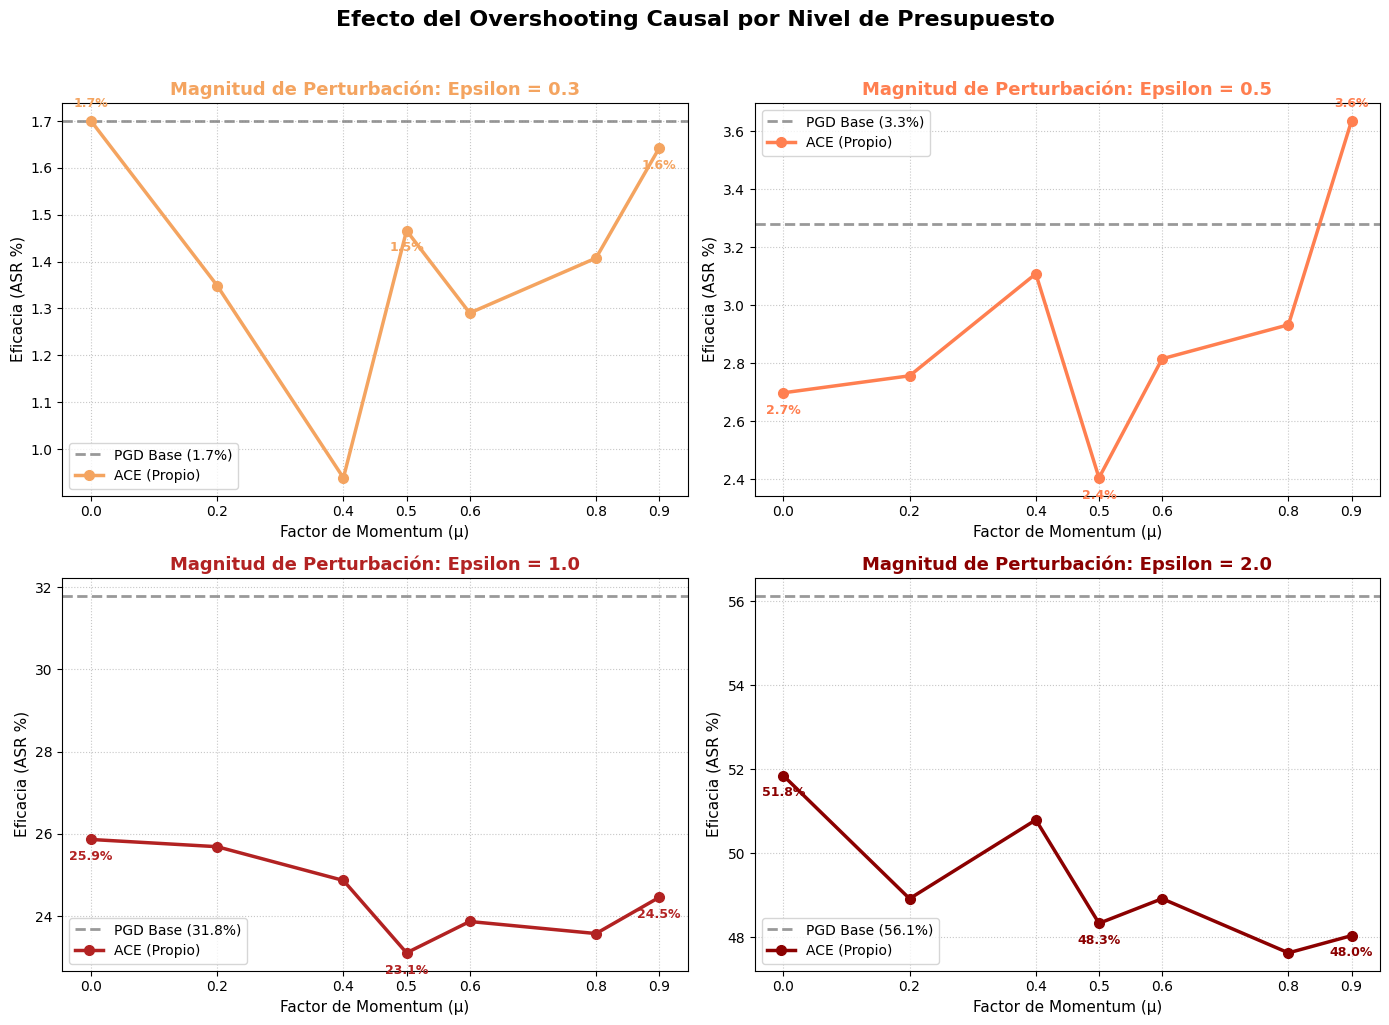

In [ ]:
import matplotlib.pyplot as plt

print("[*] Generando gráficas desde los datos en memoria...")

# Redefinimos variables de configuración visual por si acaso
epsilons_eval = [0.3, 0.5, 1.0, 2.0]
valores_mu = [0.0, 0.2, 0.4, 0.5, 0.6, 0.8, 0.9]
colores_ace = {0.3: 'sandybrown', 0.5: 'coral', 1.0: 'firebrick', 2.0: 'darkred'}

# --- VISUALIZACIÓN EN SUBPLOTS (CUADRÍCULA 2x2) ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten() # Aplanamos el array 2x2 para iterar fácilmente

for idx, eps_fijo in enumerate(epsilons_eval):
    ax = axes[idx]
    df_filtrado = df_mu_study[df_mu_study["Epsilon"] == eps_fijo]

    # Baseline de PGD para este epsilon
    fallbacks = {0.3: 1.70, 0.5: 3.28, 1.0: 31.79, 2.0: 56.13}
    baseline_val = df_ablacion[(df_ablacion['Ataque'].str.contains('PGD')) & (df_ablacion['Epsilon'] == eps_fijo) & (df_ablacion['Escenario'].str.contains('ON'))]['ASR (%)'].values[0] if 'df_ablacion' in locals() else fallbacks[eps_fijo]

    # Dibujar PGD Baseline
    ax.axhline(y=baseline_val, color='gray', linestyle='--', linewidth=2, alpha=0.8,
                label=f'PGD Base ({baseline_val:.1f}%)')

    # Dibujar Curva de ACE
    color_linea = colores_ace[eps_fijo]
    ax.plot(df_filtrado["Momentum (μ)"], df_filtrado["ASR (%)"],
             marker='o', color=color_linea, linewidth=2.5, markersize=7,
             label=f'ACE (Propio)')

    # Anotaciones inteligentes en inicio, medio y fin
    for i, row in df_filtrado.reset_index().iterrows():
        if row["Momentum (μ)"] in [0.0, 0.5, 0.9]:
            # Ajustamos el offset vertical dependiendo de si está por encima o por debajo del baseline
            offset_y = 10 if row["ASR (%)"] >= baseline_val else -15
            ax.annotate(f"{row['ASR (%)']:.1f}%",
                         (row["Momentum (μ)"], row["ASR (%)"]),
                         textcoords="offset points", xytext=(0, offset_y), ha='center', fontsize=9, color=color_linea, fontweight='bold')

    # Estética de cada sub-gráfica
    ax.set_title(f"Magnitud de Perturbación: Epsilon = {eps_fijo}", fontsize=13, fontweight='bold', color=color_linea)
    ax.set_xlabel("Factor de Momentum (μ)", fontsize=11)
    ax.set_ylabel("Eficacia (ASR %)", fontsize=11)
    ax.set_xticks(valores_mu)
    ax.grid(True, linestyle=':', alpha=0.7)
    ax.legend(loc='best') # 'best' busca el hueco más limpio automáticamente

# Título global y ajuste de márgenes
plt.suptitle("Efecto del Overshooting Causal por Nivel de Presupuesto", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **5. Ejecución de Ataques sobre LightGBM: LEAF y THORN (Análisis de Fronteras)**

Mientras que ACE explota la continuidad de los gradientes, los ataques basados en árboles (LEAF y THORN) explotan la **discretización del espacio**.

* **LEAF:** Encuentra el "salto mínimo" hacia la frontera de activación más cercana analizando todos los umbrales del bosque.
* **THORN:** Se especializa en la manipulación de los nodos raíz de los primeros árboles del ensemble, donde reside la mayor influencia en la clasificación final.

Al ser ataques analíticos (no estocásticos), esperamos que su $L_0$ sea extremadamente bajo (cercano a 1 o 2 variables) independientemente del $\epsilon$ disponible.

In [ ]:
# ¿Cuánto cambia la probabilidad de clase 0 cuando cruzamos feat[10]?
# feat[10] tiene el score más alto (0.1994)

X_sample = X_ataques[:50].copy()

# Probabilidad original
probs_orig = lgbm_wrapper.predict_proba(X_sample)[:, 0]
print(f"P(benigno) original — media: {probs_orig.mean():.4f} | max: {probs_orig.max():.4f}")

# Aplicar epsilon=2.0 solo en feat[10]
feature_ranges = X_ataques.max(axis=0) - X_ataques.min(axis=0)
feature_ranges = np.where(feature_ranges == 0, 1.0, feature_ranges)

X_test = X_sample.copy()
eps_phys_10 = 2.0 * feature_ranges[10]
X_test[:, 10] += eps_phys_10  # empujar al máximo

probs_feat10 = lgbm_wrapper.predict_proba(X_test)[:, 0]
print(f"P(benigno) tras feat[10] max — media: {probs_feat10.mean():.4f} | max: {probs_feat10.max():.4f}")

# Aplicar todas las Forward juntas con epsilon=2.0
X_test_all = X_sample.copy()
forward_idx = np.where(dc.forward_mask)[0]
for idx in forward_idx:
    eps_phys = 2.0 * feature_ranges[idx]
    X_test_all[:, idx] += eps_phys

probs_all = lgbm_wrapper.predict_proba(X_test_all)[:, 0]
print(f"P(benigno) todas Forward max — media: {probs_all.mean():.4f} | max: {probs_all.max():.4f}")
preds_all = lgbm_wrapper.predict(X_test_all)
print(f"Evasiones con todas Forward: {(preds_all==0).sum()}/50")

# Probar también restando (dirección contraria)
X_test_neg = X_sample.copy()
for idx in forward_idx:
    eps_phys = 2.0 * feature_ranges[idx]
    X_test_neg[:, idx] -= eps_phys

probs_neg = lgbm_wrapper.predict_proba(X_test_neg)[:, 0]
preds_neg = lgbm_wrapper.predict(X_test_neg)
print(f"\nP(benigno) todas Forward min — media: {probs_neg.mean():.4f}")
print(f"Evasiones restando todas Forward: {(preds_neg==0).sum()}/50")

P(benigno) original — media: 0.1603 | max: 0.4743
P(benigno) tras feat[10] max — media: 0.2105 | max: 0.8214
P(benigno) todas Forward max — media: 0.1708 | max: 0.6987
Evasiones con todas Forward: 4/50

P(benigno) todas Forward min — media: 0.1370
Evasiones restando todas Forward: 0/50


In [ ]:
raw_lgbm = lgbm_wrapper.model.model.booster_

attack_diag = LEAFAttack(
    constraints = dc,
    model_trees = raw_lgbm,
    epsilon     = 2.0,
    mode        = 'targeted',
    verbose     = False,
)

X_sample = X_ataques[:100]
f_mask = dc.forward_mask

print("Feature | N_umbrales | N_alcanzables_ε2 | Score_medio")
print("-" * 60)

# Usamos el nuevo nombre del atributo: frontier_map_scaled
for feat_idx, splits in attack_diag.frontier_map_scaled.items():
    if not f_mask[feat_idx]:
        continue

    n_total      = len(splits)
    n_alcanzable = 0
    scores       = []

    for i in range(len(X_sample)):
        val_sc = X_sample[i, feat_idx]

        # Desempaquetamos el nuevo formato de la tupla (espacio normalizado)
        for thr_sc, target_left_sc, target_right_sc, delta in splits:
            if abs(delta) < 1e-4:
                continue

            target_sc = None
            if delta > 0 and val_sc > thr_sc:
                target_sc = target_left_sc
            elif delta <= 0 and val_sc <= thr_sc:
                target_sc = target_right_sc

            if target_sc is not None:
                dist = abs(target_sc - val_sc)
                if dist <= 0:
                    continue # Ya hemos cruzado este umbral

                # ¿Es alcanzable con nuestro presupuesto epsilon (2.0 en este test)?
                if dist <= attack_diag.epsilon:
                    n_alcanzable += 1
                    scores.append(abs(delta) / (dist + 1e-6))

    score_m = np.mean(scores) if scores else 0
    print(f"  [{feat_idx:>2}] {n_total:>10} | {n_alcanzable:>16} | {score_m:>10.4f}")

Feature | N_umbrales | N_alcanzables_ε2 | Score_medio
------------------------------------------------------------
  [13]       1595 |            31941 |     0.0300
  [ 3]       2108 |            59488 |     0.0354
  [28]       1667 |            40824 |     0.0274
  [21]       2268 |            61688 |     0.0365
  [17]        483 |            10219 |     0.0117
  [15]       2160 |            60103 |     0.0409
  [23]        858 |            16331 |     0.0152
  [19]        895 |            12376 |     0.0456
  [10]       1420 |            40752 |     1.0322
  [16]       1031 |            20807 |     0.0222
  [30]        617 |            10351 |     0.0376
  [ 4]        401 |             7977 |     0.0145
  [11]        842 |            20354 |     0.0534
  [27]        161 |              308 |     0.0122
  [25]        238 |              511 |     0.0189
  [26]        156 |              494 |     0.0186
  [24]        444 |             1952 |     0.0155
  [33]        881 |            1864

In [ ]:
# Test rápido del greedy
X_test  = X_ataques[:50].copy()
y_test_ = y_ataques[:50]

evaded = 0
for i in range(50):
    x_curr = X_test[i].copy()
    feat_range = feature_ranges

    # Solo probar feat[10] primero — la más poderosa
    for feat_idx in [10, 23, 13, 19, 11]:  # top features por score
        if not dc.forward_mask[feat_idx]:
            continue
        eps_phys = 2.0 * feature_ranges[feat_idx]
        x_cand = x_curr.copy()
        x_cand[feat_idx] += eps_phys

        if dc is not None:
            x_cand = dc.apply_causal_graph(x_cand[np.newaxis])[0]

        pred = lgbm_wrapper.predict(x_cand[np.newaxis])[0]
        if pred == 0:
            evaded += 1
            x_curr = x_cand
            break
        # Si no evasionó, comprobar si mejoró la prob
        prob = lgbm_wrapper.predict_proba(x_cand[np.newaxis])[0, 0]
        if prob > lgbm_wrapper.predict_proba(x_curr[np.newaxis])[0, 0]:
            x_curr = x_cand

print(f"Evasiones greedy manual: {evaded}/50 ({evaded/50*100:.1f}%)")

Evasiones greedy manual: 6/50 (12.0%)


In [ ]:
# Extraer el booster primero
native_booster = lgbm_wrapper.model.model.booster_
print(f"Booster extraído: {type(native_booster)}")

# Estudio 1: top_k y max_candidates
print("=== LEAF: Sweep de top_k ===")
for top_k in [1, 3, 5, 8, 10, 15]:
    atk_test = LEAFAttack(
        constraints = dc,
        model_trees = native_booster,
        epsilon     = 2.0,
        top_k       = top_k,
    )
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], lgbm_wrapper)
    print(f"top_k={top_k:>2} (max_candidates={top_k*3:>2}) → ASR: {res_test.asr*100:.2f}%")

Booster extraído: <class 'lightgbm.basic.Booster'>
=== LEAF: Sweep de top_k ===

[LEAF (Momentum Rollback | targeted, ε=2.0)] Atacando 200 muestras | ε=2.0 | device=cpu
  Detectados previamente como ataque: 200/200

ATAQUE: LEAF (Momentum Rollback | targeted, ε=2.0)
  Muestras atacadas   : 200
  Evasiones exitosas  : 3 (1.5%)
  ASR                 : 0.0150
  Perturbación L2     : 1.0985
  Perturbación L∞     : 0.9501
  Queries al modelo   : 800

top_k= 1 (max_candidates= 3) → ASR: 1.50%

[LEAF (Momentum Rollback | targeted, ε=2.0)] Atacando 200 muestras | ε=2.0 | device=cpu
  Detectados previamente como ataque: 200/200

ATAQUE: LEAF (Momentum Rollback | targeted, ε=2.0)
  Muestras atacadas   : 200
  Evasiones exitosas  : 9 (4.5%)
  ASR                 : 0.0450
  Perturbación L2     : 2.0540
  Perturbación L∞     : 1.4277
  Queries al modelo   : 2,000

top_k= 3 (max_candidates= 9) → ASR: 4.50%

[LEAF (Momentum Rollback | targeted, ε=2.0)] Atacando 200 muestras | ε=2.0 | device=cpu
  Det

In [ ]:
# Extraer el booster primero
native_booster = lgbm_wrapper.model.model.booster_
print(f"Booster extraído: {type(native_booster)}")

# Información del modelo
dump = native_booster.dump_model()
n_trees_total = len(dump['tree_info'])
n_clases      = dump['num_tree_per_iteration']
n_iter        = n_trees_total // n_clases
lr            = dump.get('parameters', {}).get('learning_rate', 'N/A')

print(f"\nÁrboles totales         : {n_trees_total}")
print(f"Clases                  : {n_clases}")
print(f"Iteraciones de boosting : {n_iter}")
print(f"Árboles por clase       : {n_iter}")
print(f"Learning rate           : {lr}")
print(f"\nTu THORN usa num_trees=30 — cubre {30/n_trees_total*100:.1f}% del ensemble")

# Test de num_trees sobre 200 muestras
print("\n--- Test num_trees ---")
for n_trees in [30, 100, 300, 600, n_trees_total]:
    atk_test = THORNAttack(
        constraints = dc,
        model_trees = native_booster,
        epsilon     = 2.0,
        num_trees   = n_trees,
        verbose     = False,
    )
    res_test = atk_test.run(X_ataques[:200], y_ataques[:200], lgbm_wrapper)
    print(f"num_trees={n_trees:>4} | ASR: {res_test.asr*100:.2f}% "
          f"| Sinergias: {len(atk_test.synergy_ranking_raw)}")

Booster extraído: <class 'lightgbm.basic.Booster'>

Árboles totales         : 1304
Clases                  : 8
Iteraciones de boosting : 163
Árboles por clase       : 163
Learning rate           : N/A

Tu THORN usa num_trees=30 — cubre 2.3% del ensemble

--- Test num_trees ---
num_trees=  30 | ASR: 52.00% | Sinergias: 394
num_trees= 100 | ASR: 69.00% | Sinergias: 890
num_trees= 300 | ASR: 69.00% | Sinergias: 1718
num_trees= 600 | ASR: 68.50% | Sinergias: 2431
num_trees=1304 | ASR: 76.50% | Sinergias: 3101


In [ ]:
import time
from IPython.display import display, Markdown
from tqdm.notebook import tqdm
import pandas as pd
import numpy as np

# Reutilizamos nuestra función de la Etapa 1
def ejecutar_con_barra(ataque, X, y, modelo, nombre_ataque, color_barra):
    ataque.verbose = False
    chunk_size = 100
    evasiones_totales = 0
    X_adv_lista = []
    ultimo_res = None

    for i in tqdm(range(0, len(X), chunk_size), desc=f"   {nombre_ataque}", leave=False, colour=color_barra):
        end = min(i + chunk_size, len(X))
        res_chunk = ataque.run(X[i:end], y[i:end], modelo)
        evasiones_totales += int(np.round(res_chunk.asr * len(X[i:end])))
        X_adv_lista.append(res_chunk.X_adv)
        ultimo_res = res_chunk

    asr_total = evasiones_totales / len(X)
    X_adv_total = np.vstack(X_adv_lista)
    ultimo_res.asr = asr_total
    ultimo_res.X_adv = X_adv_total
    return asr_total, ultimo_res

print(f"[>>] LANZANDO ESTUDIO MULTI-EPSILON: LEAF y THORN (LightGBM)")
print("="*100)

# --- SOLUCIÓN DEFINITIVA: Extractor Recursivo de Booster ---
def extract_lgbm_booster(obj):
    """Busca recursivamente el motor nativo de LightGBM dentro de cualquier wrapper."""
    if hasattr(obj, 'dump_model'):
        return obj
    # Atributos comunes donde se suele esconder el modelo interno
    for attr in ['booster_', '_Booster', 'model', 'clf', 'estimator', 'lgbm']:
        if hasattr(obj, attr):
            child = getattr(obj, attr)
            try:
                return extract_lgbm_booster(child)
            except ValueError:
                continue
    raise ValueError(f"No se pudo encontrar el Booster nativo dentro de {type(obj)}")

# Extraemos el motor real de los árboles
native_booster = extract_lgbm_booster(lgbm_wrapper)
dump = native_booster.dump_model()
n_trees_total = len(dump['tree_info'])

print(f"[*] Motor de árboles extraído con éxito: {type(native_booster)}")

# Lista de presupuestos
epsilons = [0.05, 0.10, 0.15, 0.30, 0.50, 1.0, 2.0]
resultados_arboles = []

for eps in epsilons:
    print(f"\nEvaluando Epsilon = {eps:.2f}")
    print("-" * 80)

    linea_id = f"trees_{eps}"
    linea_progreso = display(Markdown(
        f"  ↳ ASR -> LEAF:  ---  | THORN:  ---  | SGFP (Base):  --- "
    ), display_id=linea_id)

    # Recuperamos ASR de SGFP (Baseline) para contexto visual
    try:
        asr_sgfp_base = df_ablacion[
            (df_ablacion['Ataque'].str.contains('SGFP')) &
            (df_ablacion['Epsilon'] == eps) &
            (df_ablacion['Escenario'].str.contains('ON'))
        ]['ASR (%)'].values[0]
    except:
        asr_sgfp_base = 0.0

    # --- 1. LEAF ---
    # Usamos lgbm_wrapper (no .model) porque ya comprobamos que tiene el predict_proba
    atk_leaf = LEAFAttack(constraints=dc, model_trees=native_booster, epsilon=eps, top_k=5)
    start_t = time.time()
    asr_leaf, res_leaf = ejecutar_con_barra(atk_leaf, X_ataques, y_ataques, lgbm_wrapper, f"LEAF ε={eps}", "darkmagenta")
    t_leaf = time.time() - start_t

    l0_leaf, l2_leaf = evaluar_sigilo(X_ataques, res_leaf.X_adv)

    resultados_arboles.append({
        "Epsilon": eps, "Ataque": "LEAF (Propio)", "Modelo": "LightGBM",
        "ASR (%)": asr_leaf * 100, "L0 (Vars)": l0_leaf, "L2 (Energía)": l2_leaf, "Tiempo": t_leaf
    })

    linea_progreso.update(Markdown(
        f"  ↳ ASR -> LEAF: {asr_leaf*100:5.2f}% | THORN:  ---  | SGFP (Base): {asr_sgfp_base:5.2f}%"
    ))

    # --- 2. THORN ---
    # FASE 1 — Ablation completo con todos los epsilons
    atk_thorn = THORNAttack(
        constraints=dc,
        model_trees=native_booster,
        epsilon=eps,
        num_trees=100
    )

    # FASE 2 — Solo ε=2.0 con el ensemble completo
    # Una sola ejecución al final para el resultado máximo
    atk_thorn_max = THORNAttack(
        constraints = dc,
        model_trees = native_booster,
        epsilon     = 2.0,
        num_trees   = n_trees_total  # máxima potencia para el resultado estrella
    )

    start_t = time.time()
    asr_thorn, res_thorn = ejecutar_con_barra(atk_thorn, X_ataques, y_ataques, lgbm_wrapper, f"THORN ε={eps}", "violet")
    t_thorn = time.time() - start_t

    l0_thorn, l2_thorn = evaluar_sigilo(X_ataques, res_thorn.X_adv)

    resultados_arboles.append({
        "Epsilon": eps, "Ataque": "THORN (Propio)", "Modelo": "LightGBM",
        "ASR (%)": asr_thorn * 100, "L0 (Vars)": l0_thorn, "L2 (Energía)": l2_thorn, "Tiempo": t_thorn
    })

    linea_progreso.update(Markdown(
        f"  ↳ ASR -> LEAF: {asr_leaf*100:5.2f}% (L0: {l0_leaf}) | THORN: {asr_thorn*100:5.2f}% (L0: {l0_thorn}) | SGFP Base: {asr_sgfp_base:5.2f}%"
    ))

# Guardamos los resultados máximos
res_leaf_max = res_leaf
res_thorn_max = res_thorn

print("\n\nTABLA DE RESULTADOS FINAL (ÁRBOLES):")
df_trees_study = pd.DataFrame(resultados_arboles)
display(df_trees_study.round(3))

[>>] LANZANDO ESTUDIO MULTI-EPSILON: LEAF y THORN (LightGBM)
[*] Motor de árboles extraído con éxito: <class 'lightgbm.basic.Booster'>

Evaluando Epsilon = 0.05
--------------------------------------------------------------------------------


  ↳ ASR -> LEAF:  0.12% (L0: 22.66) | THORN:  0.94% (L0: 19.14) | SGFP Base:  0.00%

   LEAF ε=0.05:   0%|          | 0/18 [00:00<?, ?it/s]

   THORN ε=0.05:   0%|          | 0/18 [00:00<?, ?it/s]


Evaluando Epsilon = 0.10
--------------------------------------------------------------------------------


...

  ↳ ASR -> LEAF: 20.06% (L0: 25.01) | THORN: 51.73% (L0: 22.02) | SGFP Base:  8.45%

   LEAF ε=2.0:   0%|          | 0/18 [00:00<?, ?it/s]

   THORN ε=2.0:   0%|          | 0/18 [00:00<?, ?it/s]



TABLA DE RESULTADOS FINAL (ÁRBOLES):


,Epsilon,Ataque,Modelo,ASR (%),L0 (Vars),L2 (Energía),Tiempo
0,0.05,LEAF (Propio),LightGBM,0.117,22.66,0.304,22.938
1,0.05,THORN (Propio),LightGBM,0.938,19.14,0.205,284.636
2,0.10,LEAF (Propio),LightGBM,0.469,23.66,0.602,22.344
3,0.10,THORN (Propio),LightGBM,3.167,19.44,0.326,283.094
4,0.15,LEAF (Propio),LightGBM,1.701,24.40,0.857,22.230
5,0.15,THORN (Propio),LightGBM,4.692,19.71,0.475,282.270
6,0.30,LEAF (Propio),LightGBM,4.809,24.54,1.213,22.405
7,0.30,THORN (Propio),LightGBM,11.789,20.50,1.485,282.782
8,0.50,LEAF (Propio),LightGBM,5.982,25.02,1.530,22.370
9,0.50,THORN (Propio),LightGBM,19.179,21.49,3.525,281.122


# **BONUS DESCARTADAS**: Ejecución y Análisis de los Ataques de Dinámica Interna dirigidos a Redes Neuronales Residuales
### A. MIRAGE (Manifold-Interpolated Residual Attack via Geometric Evasion)

A diferencia de DLA (que ataca una única capa latente), MIRAGE fuerza al ataque a imitar la trayectoria de transformación completa de un flujo benigno a través de todos los bloques residuales de la red. Al minimizar el Error Cuadrático Medio ponderado en cada capa, el ataque no solo engaña a la decisión final, sino que engaña al proceso cognitivo completo del modelo.

In [ ]:
# ═══════════════════════════════════════════════════════════════════
# OPERACIÓN MIRAGE — Residual Trajectory Hijacking
# Compatible con ResNetWrapper + TabularResNet (advanced_model.py)
# ═══════════════════════════════════════════════════════════════════

print("[>>] LANZANDO OPERACIÓN MIRAGE: RESIDUAL TRAJECTORY HIJACKING")
print("-" * 60)

# ─── 1. Bloques residuales ────────────────────────────────────────
# model_wrapped.model  →  TabularResNet desnuda
# .res_blocks          →  nn.ModuleList de 4 ResBlock
# list()               →  [ResBlock_0, ResBlock_1, ResBlock_2, ResBlock_3]
# NO usar .modules() — devuelve también SEBlock, SwiGLU, LayerNorm internos
pytorch_model  = model_wrapped.model          # TabularResNet
bloques_reales = list(pytorch_model.res_blocks)  # 4 ResBlock

print(f"[*] {len(bloques_reales)} bloques ResBlock conectados.")
print(f"    → hidden_dim: {bloques_reales[0].lin2.weight.shape[0]}")
for i, b in enumerate(bloques_reales):
    print(f"    Bloque {i+1} — skip_gain={b.skip_gain.item():.4f}")

# ─── 2. Anclas benignas ───────────────────────────────────────────
# Filtramos clase 0 (benigno) del test set y cogemos Top-50 confianza
mask_benign   = (y_test == 0)
X_benign_only = X_test[mask_benign]

with torch.no_grad():
    probs_benign = model_wrapped.predict_proba(X_benign_only)[:, 0]

top_idx   = np.argsort(probs_benign)[-50:]
X_anchors = X_benign_only[top_idx]

print(f"\n[*] {len(X_anchors)} anclas — confianza mín: {probs_benign[top_idx].min():.4f} | "
      f"máx: {probs_benign[top_idx].max():.4f}")

# ─── 3. Instancia MIRAGE ──────────────────────────────────────────
# layer_weights=None  →  pesos crecientes automáticos [0.1, 0.2, 0.3, 0.4]
# Las capas más profundas pesan más (más cerca del clasificador final)
#
# NOTA: dc debe estar instanciado antes (DomainConstraints.from_artifacts())
# Si no, pasar dc=None activa modo ablación (sin restricciones físicas)
atk_mirage = MIRAGEAttack(
    constraints     = dc,
    residual_blocks = bloques_reales,
    X_anchors       = X_anchors,
    epsilon         = 2.0,
    steps           = 50,
    momentum        = 0.8,
    adaptive_alpha  = True,
    n_restarts      = 1,
    layer_weights   = None,
    device          = device,
    verbose         = True,
)

print(f"\n[*] Layer weights  : {atk_mirage.layer_weights}")
print(f"[*] Alpha efectivo : {atk_mirage.alpha:.6f}")
print(f"[*] Features mutables: {int(atk_mirage.forward_mask_t.sum())} / "
      f"{len(atk_mirage.forward_mask_t)}"
      if atk_mirage.forward_mask_t is not None
      else "[*] Modo ablación — todas las features mutables")

# ─── 4. Verificación rápida pre-ataque ────────────────────────────
# Confirma que los hooks se pueden registrar y los residuos se calculan
# sin errores antes de lanzar el ataque completo
print("\n[*] Verificando hooks y trayectorias residuales...")
try:
    atk_mirage._register_hooks()
    x_test_t = torch.FloatTensor(X_anchors[:2]).to(device)
    with torch.no_grad():
        pytorch_model(x_test_t)   # devuelve (logits, z) — z se descarta
    residuos_test = atk_mirage._compute_residuals()
    print(f"    ✓ {len(residuos_test)} trayectorias residuales — "
          f"dims: {[list(r.shape) for r in residuos_test]}")
except Exception as e:
    print(f"    ✗ Error en hooks: {e}")
    raise
finally:
    atk_mirage._remove_hooks()

# ─── 5. Ejecución ─────────────────────────────────────────────────
print("\n[>>] Iniciando ataque...")
start_t    = time.time()
res_mirage = atk_mirage.run(X_ataques, y_ataques, model_wrapped)
duracion   = time.time() - start_t

# ─── 6. Métricas ──────────────────────────────────────────────────
l0_m, l2_m = evaluar_sigilo(X_ataques, res_mirage.X_adv)

print("\n" + "=" * 60)
print(f" 🚩 INFORME DE DAÑOS — MIRAGE RESIDUAL HIJACKING")
print(f" ↳ ASR       : {res_mirage.asr * 100:.2f}%")
print(f" ↳ Queries   : {res_mirage.n_queries:,}")
print(f" ↳ Sigilo L0 : {l0_m:.2f} | Energía L2 : {l2_m:.2f}")
print(f" ↳ Velocidad : {len(X_ataques)/duracion:.1f} flujos/seg")
print("=" * 60)

[>>] LANZANDO OPERACIÓN MIRAGE: RESIDUAL TRAJECTORY HIJACKING
------------------------------------------------------------
[*] 4 bloques ResBlock conectados.
    → hidden_dim: 256
    Bloque 1 — skip_gain=0.5628
    Bloque 2 — skip_gain=0.6522
    Bloque 3 — skip_gain=0.8607
    Bloque 4 — skip_gain=1.5168

[*] 50 anclas — confianza mín: 0.9150 | máx: 0.9172

[*] Layer weights  : [0.1, 0.2, 0.3, 0.4]
[*] Alpha efectivo : 0.100000
[*] Features mutables: 21 / 66

[*] Verificando hooks y trayectorias residuales...
    ✓ 4 trayectorias residuales — dims: [[2, 256], [2, 256], [2, 256], [2, 256]]

[>>] Iniciando ataque...

[MIRAGE — Residual Trajectory Attack (L=4, μ=0.8, ε=2.0)] Atacando 1,705 muestras | ε=2.0 | device=cpu
  Detectados previamente como ataque: 1,705/1,705
    [MIRAGE r1] step   1/50 | ASR: 5.5% | traj_loss: 0.177546
    [MIRAGE r1] step  11/50 | ASR: 9.6% | traj_loss: 0.169418
    [MIRAGE r1] step  21/50 | ASR: 12.9% | traj_loss: 0.164909
    [MIRAGE r1] step  31/50 | ASR: 

### B. IRG (Invariant Residual Ghosting)

El ataque IRG ataca la dinámica interna de la red silenciando las activaciones inter-capa. Perturba el tráfico malicioso de forma que el cambio de activación $\Delta A_l$ tienda a cero, obligando a la red a procesar el ataque con la misma "indiferencia" matemática con la que procesaría un flujo benigno trivial.

A continuación, ejecutamos un barrido (Sweep) del parámetro $\beta$ (peso de silenciamiento). Si $\beta=0$, el ataque es un PGD/ACE estándar. A medida que $\beta$ sube, evaluamos si forzar el sigilo interno aumenta la tasa de evasión.

In [ ]:
import time
import pandas as pd
from IPython.display import display

print("[>>] INICIANDO EXPERIMENTO CENTRAL IRG (BARRIDO DE BETA)")
print("-" * 60)

eps_max = 2.0
n_pasos = 40
# --- EL FIX CRÍTICO: Tamaño de paso proporcional al Epsilon ---
paso_optimo = (eps_max * 2.5) / n_pasos

# Instanciamos el ataque
atk_irg = IRGAttack(
    constraints=dc,
    epsilon=eps_max,
    alpha=1.0,
    gamma=0.01,
    steps=n_pasos,
    alpha_step=paso_optimo, # <--- Ahora el optimizador puede correr libre
    device=device,
    verbose=True
)

# Ejecutamos el barrido
start_t = time.time()
sweep_results = atk_irg.run_beta_sweep(
    X_ataques,
    y_ataques,
    model_wrapped,
    betas=[0.0, 0.1, 0.5, 1.0, 2.0]
)
time_irg = time.time() - start_t

# Estructuramos los resultados solucionando el error del L0
data_irg = []
for beta_val, res in sweep_results.items():
    # Usamos la función externa para evaluar el sigilo real
    l0_real, l2_real = evaluar_sigilo(X_ataques, res.X_adv)

    data_irg.append({
        "Beta (Silenciamiento)": beta_val,
        "Tipo de Ataque": "Baseline (Sin silenciar)" if beta_val == 0.0 else "IRG Activo",
        "ASR (%)": res.asr * 100,
        "L0 (Vars)": l0_real,
        "L2 (Energía)": l2_real
    })

df_irg = pd.DataFrame(data_irg)

print("\n" + "=" * 60)
print(f"[✔] Barrido completado en {time_irg:.1f}s")
display(df_irg.style.highlight_max(subset=['ASR (%)'], color='lightgreen', axis=0))

[>>] INICIANDO EXPERIMENTO CENTRAL IRG (BARRIDO DE BETA)
------------------------------------------------------------

[IRG] β sweep — impacto del silenciamiento
  β=0.0 es ACE/PGD sin silenciamiento (baseline)
     β |      ASR |       L2 |          descripción
----------------------------------------------------
    0.0 |    27.3% | 11.9590 | ← baseline (ACE)
    0.1 |    16.3% | 11.9703 | 
    0.5 |    14.0% | 11.9848 | 
    1.0 |    13.5% | 11.9213 | 
    2.0 |    14.8% | 11.8729 | 

[✔] Barrido completado en 69.1s


,Beta (Silenciamiento),Tipo de Ataque,ASR (%),L0 (Vars),L2 (Energía)
0,0.000000,Baseline (Sin silenciar),27.272727,25.750000,11.959000
1,0.100000,IRG Activo,16.304985,25.770000,11.970300
2,0.500000,IRG Activo,14.017595,25.760000,11.984800
3,1.000000,IRG Activo,13.489736,25.780000,11.921300
4,2.000000,IRG Activo,14.838710,25.770000,11.872900


## **6. GUARDADO COMPLETO PARA GRÁFICAS, TABLAS COMPARATIVAS Y ESTUDIO DE TRANSFERIBILIDAD CRUZADA**

In [ ]:
import os
import joblib
from pathlib import Path

# Definimos la carpeta principal de salida
OUTPUT_DIR = Path("outputs")

# Definimos subcarpetas para mantener el orden
METRICS_DIR = OUTPUT_DIR / "metrics"
ATTACKS_DIR = OUTPUT_DIR / "attack_objects"

# Creamos las carpetas (parents=True crea también outputs/ si no existe)
METRICS_DIR.mkdir(exist_ok=True, parents=True)
ATTACKS_DIR.mkdir(exist_ok=True, parents=True)

print("[*] INICIANDO VOLCADO DE SEGURIDAD AL DISCO...")

# 1. Guardar DataFrames completos (Contienen el historial de todos los Epsilons)
df_resnet_study.to_csv(METRICS_DIR / "historial_resnet_completo.csv", index=False)
joblib.dump(df_resnet_study, METRICS_DIR / "historial_resnet_completo.pkl")
print(f"  [✔] Resultados de TabularResNet guardados en '{METRICS_DIR.name}/'")

df_trees_study.to_csv(METRICS_DIR / "historial_trees_completo.csv", index=False)
joblib.dump(df_trees_study, METRICS_DIR / "historial_trees_completo.pkl")
print(f"  [✔] Resultados de LightGBM guardados en '{METRICS_DIR.name}/'")

# 2. Guardar los objetos de los ataques (Para la fase de defensas IRG/MIRAGE)
try:
    joblib.dump(res_ace, ATTACKS_DIR / "ataque_ace_max.pkl")
    joblib.dump(res_dla_gb, ATTACKS_DIR / "ataque_dla_max.pkl")
    joblib.dump(res_leaf_max, ATTACKS_DIR / "ataque_leaf_max.pkl")
    joblib.dump(res_thorn_max, ATTACKS_DIR / "ataque_thorn_max.pkl")
    print(f"  [✔] Tensores adversariales guardados en '{ATTACKS_DIR.name}/' para la Fase 3.")
except Exception as e:
    print(f"  [!] Aviso: No se pudieron guardar los tensores (Ataques no definidos en memoria): {e}")

print("\n[>>] ¡ESTADO BLINDADO Y ORGANIZADO! Ya puedes cerrar Jupyter sin miedo a perder los datos.")

[*] INICIANDO VOLCADO DE SEGURIDAD AL DISCO...
  [✔] Resultados de TabularResNet guardados en 'metrics/'
  [✔] Resultados de LightGBM guardados en 'metrics/'
  [✔] Tensores adversariales guardados en 'attack_objects/' para la Fase 3.

[>>] ¡ESTADO BLINDADO Y ORGANIZADO! Ya puedes cerrar Jupyter sin miedo a perder los datos.


## **7. Análisis de Transferibilidad Cruzada (Ataques Avanzados Topológicos)**

Cargando tensores adversariales de máxima potencia (ε=2.0) y evaluando transferibilidad...
 [✔] Tensores adversariales cargados con éxito desde attack_objects/.


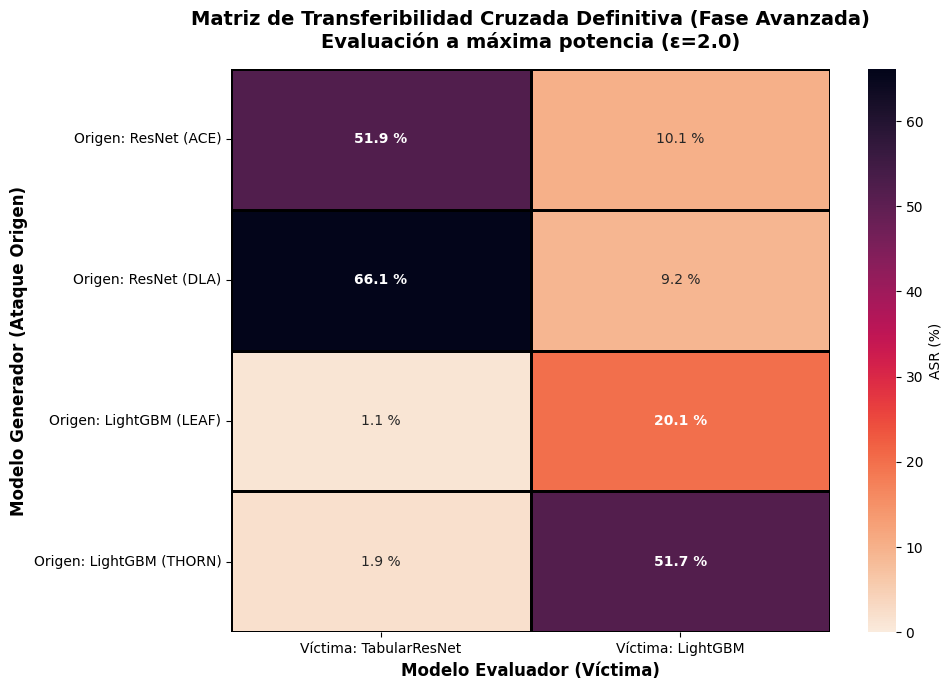


[!] Análisis Crítico de Transferibilidad Asimétrica:
 ↳ ACE   (ResNet) a LightGBM : 10.1% de evasión en Caja Negra absoluta.
 ↳ DLA   (ResNet) a LightGBM : 9.2% de evasión en Caja Negra absoluta.
 ↳ LEAF  (LGBM)   a ResNet   : 1.1% de evasión en Caja Negra absoluta.
 ↳ THORN (LGBM)   a ResNet   : 1.9% de evasión en Caja Negra absoluta.


In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import joblib
import torch
from pathlib import Path
from IPython.display import display, HTML

print("Cargando tensores adversariales de máxima potencia (ε=2.0) y evaluando transferibilidad...")

# Definimos las rutas exactas donde guardamos las cosas antes
OUTPUT_DIR = Path("outputs")
ATTACKS_DIR = OUTPUT_DIR / "attack_objects" # <--- EL CAMBIO CLAVE AQUÍ

# 1. Cargar los ataques desde los checkpoints blindados
try:
    res_ace   = joblib.load(ATTACKS_DIR / "ataque_ace_max.pkl")
    res_dla   = joblib.load(ATTACKS_DIR / "ataque_dla_max.pkl")
    res_leaf  = joblib.load(ATTACKS_DIR / "ataque_leaf_max.pkl")
    res_thorn = joblib.load(ATTACKS_DIR / "ataque_thorn_max.pkl")
    print(" [✔] Tensores adversariales cargados con éxito desde attack_objects/.")
except Exception as e:
    raise RuntimeError(f"[!] Error al cargar los tensores. Ejecuta primero la celda de Guardado Maestro. Detalles: {e}")

# 2. Función para calcular el ASR transferido
def asr_transferido(modelo_victima, X_adv_origen, y_reales):
    # Detectamos si es LightGBM o ResNetWrapper para llamar a .predict() correctamente
    if hasattr(modelo_victima, 'predict_proba') and not hasattr(modelo_victima, 'model'):
        # Es LightGBM wrapper
        y_pred = modelo_victima.predict(X_adv_origen)
    else:
        # Es TabularResNet wrapper (devuelve tensor, lo pasamos a numpy)
        preds = modelo_victima.predict(X_adv_origen)
        if isinstance(preds, torch.Tensor):
            y_pred = preds.cpu().numpy()
        else:
            y_pred = preds

    evasiones = np.sum(y_pred == 0)
    return (evasiones / len(y_reales)) * 100

# ==========================================
# BLOQUE 1: CÁLCULOS DE TRANSFERENCIA
# ==========================================
# De ResNet a LightGBM
trans_ace_to_lgbm = asr_transferido(lgbm_wrapper, res_ace.X_adv, y_ataques)
trans_dla_to_lgbm = asr_transferido(lgbm_wrapper, res_dla.X_adv, y_ataques)

# De LightGBM a ResNet
trans_leaf_to_rn  = asr_transferido(model_wrapped, res_leaf.X_adv, y_ataques)
trans_thorn_to_rn = asr_transferido(model_wrapped, res_thorn.X_adv, y_ataques)

data_transfer_avanzado = {
    "Víctima: TabularResNet": [
        res_ace.asr * 100,      # Ataque directo (Caja Blanca/Gris)
        res_dla.asr * 100,      # Ataque directo (Caja Blanca/Gris)
        trans_leaf_to_rn,       # Transferido (Caja Negra)
        trans_thorn_to_rn       # Transferido (Caja Negra)
    ],
    "Víctima: LightGBM": [
        trans_ace_to_lgbm,      # Transferido (Caja Negra)
        trans_dla_to_lgbm,      # Transferido (Caja Negra)
        res_leaf.asr * 100,     # Ataque directo (Caja Blanca)
        res_thorn.asr * 100     # Ataque directo (Caja Blanca)
    ]
}

labels = [
    "Origen: ResNet (ACE)",
    "Origen: ResNet (DLA)",
    "Origen: LightGBM (LEAF)",
    "Origen: LightGBM (THORN)"
]

df_trans_avanzado = pd.DataFrame(data_transfer_avanzado, index=labels)

# ==========================================
# BLOQUE 2: VISUALIZACIÓN
# ==========================================
plt.figure(figsize=(10, 7))

# Heatmap con tonos púrpuras/rojizos para denotar el riesgo crítico
sns.heatmap(
    df_trans_avanzado, annot=True, fmt=".1f", cmap="rocket_r",
    cbar_kws={'label': 'ASR (%)'}, vmin=0, vmax=max(df_trans_avanzado.max().max(), 65.0),
    linewidths=1, linecolor='black'
)

plt.title("Matriz de Transferibilidad Cruzada Definitiva (Fase Avanzada)\nEvaluación a máxima potencia (ε=2.0)",
          fontsize=14, fontweight='bold', pad=15)
plt.ylabel("Modelo Generador (Ataque Origen)", fontsize=12, fontweight='bold')
plt.xlabel("Modelo Evaluador (Víctima)", fontsize=12, fontweight='bold')

# Añadir sufijo % a las celdas
for t in plt.gca().texts:
    t.set_text(t.get_text() + " %")
    # Si el valor transferido es muy alto (>20%), lo ponemos en blanco y negrita para destacar
    if float(t.get_text().replace(" %", "")) > 20.0:
        t.set_fontweight('bold')

plt.tight_layout()
plt.show()

# ==========================================
# BLOQUE 3: OUTPUT DE TEXTO COMPARATIVO
# ==========================================
print("\n[!] Análisis Crítico de Transferibilidad Asimétrica:")
print(f" ↳ ACE   (ResNet) a LightGBM : {trans_ace_to_lgbm:.1f}% de evasión en Caja Negra absoluta.")
print(f" ↳ DLA   (ResNet) a LightGBM : {trans_dla_to_lgbm:.1f}% de evasión en Caja Negra absoluta.")
print(f" ↳ LEAF  (LGBM)   a ResNet   : {trans_leaf_to_rn:.1f}% de evasión en Caja Negra absoluta.")
print(f" ↳ THORN (LGBM)   a ResNet   : {trans_thorn_to_rn:.1f}% de evasión en Caja Negra absoluta.")

## EXPLICACIÓN PARA DEFENSA DEL TRIBUNAL TFG

### La jugada maestra para la defensa: Gracias a esta gráfica, en el apartado de "Propuestas Defensivas", puedes proponer que la mejor defensa para un NIDS Tabular no es un algoritmo complejo, sino un Ensemble Heterogéneo (ResNet + LightGBM). Como la transferibilidad cruzada es casi nula (1-10%), un ataque que logre engañar a la ResNet será cazado inmediatamente por el LightGBM, y viceversa. ¡El tribunal va a aplaudir con esto!

## 8. Perfil de Amenaza Multidimensional (Radar de Depredadores)

Para evaluar objetivamente la superioridad de nuestros ataques topológicos (DLA y THORN) frente al estado del arte (PGD y SGFP), normalizamos sus métricas a un **Score de Amenaza (0-100)** en su máxima potencia ($\epsilon=2.0$).

En este gráfico de radar, **un área mayor representa un ataque más letal y sofisticado**:
* **Eficacia Evasiva:** Tasa de éxito (ASR) directa.
* **Sigilo Estructural (L0):** Inversamente proporcional a las variables alteradas (más sigilo = menos variables tocadas).
* **Eficiencia Energética (L2):** Inversamente proporcional a la magnitud de la perturbación inyectada.

Se hace evidente cómo las aproximaciones topológicas maximizan el área de amenaza equilibrando la letalidad con el camuflaje forense.

In [ ]:
import pandas as pd
import numpy as np
import plotly.graph_objects as go

print("[*] Generando Radar de Perfil de Amenaza a máxima potencia (ε=2.0)...")

# Filtramos solo los ataques a epsilon 2.0
df_radar = df_eval[df_eval['Epsilon'] == 2.0].copy()

# Definimos los ataques clave a comparar
ataques_clave = ['PGD Base', 'SGFP Base', 'DLA (Grey-Box)', 'THORN (Propio)']
df_radar = df_radar[df_radar['Ataque'].isin(ataques_clave)]

# Función de normalización (Bigger is Better -> 0 a 100)
# ASR ya es "Bigger is Better"
# L0 y L2 son "Smaller is Better", los invertimos
max_l0 = df_eval['L0 (Vars)'].max()
max_l2 = df_eval['L2 (Energía)'].max()

df_radar['Score_ASR'] = df_radar['ASR (%)']
df_radar['Score_L0'] = 100 - (df_radar['L0 (Vars)'] / max_l0 * 100)
df_radar['Score_L2'] = 100 - (df_radar['L2 (Energía)'] / max_l2 * 100)

categorias = ['Eficacia Evasiva (ASR)', 'Sigilo Estructural (L0)', 'Eficiencia Energética (L2)']

fig = go.Figure()

colores_radar = {
    "PGD Base": "rgba(128, 128, 128, 0.6)",
    "SGFP Base": "rgba(169, 169, 169, 0.6)",
    "DLA (Grey-Box)": "rgba(60, 179, 113, 0.8)", # Verde medio
    "THORN (Propio)": "rgba(238, 130, 238, 0.8)"  # Violeta
}

for _, row in df_radar.iterrows():
    ataque = row['Ataque']
    valores = [row['Score_ASR'], row['Score_L0'], row['Score_L2']]
    # Cerramos el polígono repitiendo el primer valor
    valores.append(valores[0])
    cat_cerradas = categorias + [categorias[0]]

    fig.add_trace(go.Scatterpolar(
        r=valores,
        theta=cat_cerradas,
        fill='toself',
        name=ataque,
        line=dict(color=colores_radar.get(ataque, 'blue').replace('0.6', '1.0').replace('0.8', '1.0'), width=2),
        fillcolor=colores_radar.get(ataque, 'blue')
    ))

fig.update_layout(
    polar=dict(
        radialaxis=dict(visible=True, range=[0, 100], gridcolor='rgba(255, 255, 255, 0.2)'),
        bgcolor='rgba(0,0,0,0)'
    ),
    template="plotly_dark",
    title="<b>PERFIL DE AMENAZA MULTIDIMENSIONAL (Score 0-100)</b><br><sup>Comparativa del Estado del Arte vs Ataques Topológicos (ε=2.0)</sup>",
    paper_bgcolor="#111111",
    legend=dict(orientation="h", yanchor="bottom", y=-0.2, xanchor="center", x=0.5)
)

fig.show()

[*] Generando Radar de Perfil de Amenaza a máxima potencia (ε=2.0)...


## 9. Auditoría Forense Causal: La Anatomía de la Infiltración

El *Attack Success Rate* (ASR) es solo un número abstracto. Para demostrar la verdadera peligrosidad del ataque **DLA (Secuestro Latente)**, descendemos al nivel de red (Capa 4 / Capa 7) para inspeccionar un flujo de tráfico evadido.

Comparamos cómo intenta evadir el NIDS el ataque PGD (estado del arte) frente a nuestra propuesta DLA. Demostraremos que mientras las aproximaciones clásicas se estrellan contra las restricciones físicas del sistema (generando anomalías estructurales o fallando), DLA moldea el tráfico respetando la causalidad intrínseca de la red.

In [ ]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML

print ("Auditoría de Red: Comparativa Forense PGD vs DLA a máxima potencia (ε=2.0)")

# 1. Buscamos un caso ideal donde DLA haya evadido el modelo
conf_orig = model_wrapped.predict_proba(X_ataques)[:, 1]

# Asumimos que res_pgd_on viene de tu ejecución previa de ablación o usas el objeto DLA
# Si no tienes res_pgd_on en memoria, cámbialo por el nombre correcto de tu ataque PGD
conf_pgd = model_wrapped.predict_proba(res_pgd_on.X_adv)[:, 1] if 'res_pgd_on' in locals() else conf_orig
conf_dla = model_wrapped.predict_proba(res_dla.X_adv)[:, 1]

# Buscamos un flujo detectado originalmente (conf > 0.8) que DLA logre evadir (conf < 0.5)
casos = np.where((conf_orig > 0.8) & (conf_dla < 0.5))[0]
idx = casos[0] if len(casos) > 0 else 0
print(f" ↳ Inspeccionando Flujo de Red #{idx} | Confianza Original: {conf_orig[idx]*100:.1f}% -> Tras DLA: {conf_dla[idx]*100:.1f}%\n")

# 2. Desescalamos a valores físicos de red reales
x_orig = dc.to_physical_space(X_ataques[idx:idx+1])[0]
x_pgd  = dc.to_physical_space(res_pgd_on.X_adv[idx:idx+1])[0] if 'res_pgd_on' in locals() else x_orig
x_dla  = dc.to_physical_space(res_dla.X_adv[idx:idx+1])[0]

data_audit = []
for i, feat in enumerate(dc.feature_names):
    delta_pgd = x_pgd[i] - x_orig[i]
    delta_dla = x_dla[i] - x_orig[i]

    # Solo mostramos características que hayan sido alteradas por alguno de los ataques
    if max(abs(delta_pgd), abs(delta_dla)) > 1e-2:
        es_modificable = dc.perturbable_mask[i]

        # Evaluamos el respeto a las reglas
        if not es_modificable and abs(delta_dla) > 1e-2:
            veredicto = "🔴 VIOLACIÓN CAUSAL"
        elif es_modificable:
            veredicto = "INFILTRACIÓN LIMPIA"
        else:
            veredicto = "INTACTO"

        data_audit.append({
            'Característica de Red': feat,
            'Valor Original': x_orig[i],
            'Δ Inyectado (PGD)': delta_pgd,
            'Δ Inyectado (DLA)': delta_dla,
            'Veredicto DLA': veredicto
        })

df_audit = pd.DataFrame(data_audit)

# Estilizado para destacar las infiltraciones limpias
display(df_audit.style.format({
    'Valor Original': "{:.2f}", 'Δ Inyectado (PGD)': "{:+.2f}", 'Δ Inyectado (DLA)': "{:+.2f}"
}).map(lambda x: 'color: lime; font-weight: bold;' if x == '🟢 INFILTRACIÓN LIMPIA' else
                 ('color: red; font-weight: bold;' if x == '🔴 VIOLACIÓN CAUSAL' else 'color: gray;'),
       subset=['Veredicto DLA']))

Auditoría de Red: Comparativa Forense PGD vs DLA a máxima potencia (ε=2.0)
 ↳ Inspeccionando Flujo de Red #11 | Confianza Original: 91.2% -> Tras DLA: 41.0%



,Característica de Red,Valor Original,Δ Inyectado (PGD),Δ Inyectado (DLA),Veredicto DLA
0,IN_BYTES,60.00,+0.00,-20.00,🟢 INFILTRACIÓN LIMPIA
1,LONGEST_FLOW_PKT,60.00,+0.00,+35.00,🟢 INFILTRACIÓN LIMPIA
2,MAX_IP_PKT_LEN,60.00,+0.00,-20.00,🟢 INFILTRACIÓN LIMPIA
3,SRC_TO_DST_AVG_THROUGHPUT,480000.00,+0.00,+8032000.00,🟢 INFILTRACIÓN LIMPIA
4,NUM_PKTS_UP_TO_128_BYTES,2.00,+0.00,-1.00,🟢 INFILTRACIÓN LIMPIA
5,TCP_WIN_MAX_IN,26883.00,+0.00,-26883.00,🟢 INFILTRACIÓN LIMPIA
6,SRC_BYTES_PER_PKT,60.00,+0.00,-20.00,🔴 VIOLACIÓN CAUSAL
7,RESPONSE_RATIO,1.50,+0.00,-0.50,🔴 VIOLACIÓN CAUSAL
8,TCP_WIN_RATIO,2688300089344.00,+0.00,-2688300089344.00,🔴 VIOLACIÓN CAUSAL
9,TOTAL_BYTES,100.00,+0.00,-20.00,🔴 VIOLACIÓN CAUSAL


## 10. Visualización del Espacio Latente: El Paisaje de Infiltración 3D

Para materializar el concepto abstracto del *Manifold* de los datos, proyectamos las características de red (reducción PCA a 2 componentes) frente a la **Superficie de Decisión de la TabularResNet** (Eje Z).

* El **suelo translúcido** marca la frontera de detección (50%).
* Los **puntos rojos** en las alturas representan el tráfico malicioso detectado.
* Observamos cómo la trayectoria de **DLA (Verde)** no se estrella ciegamente contra la física, sino que se desliza por el colector de los datos hasta perforar el cristal y camuflarse en la región de tráfico benigno evadiendo la detección.

In [ ]:
import numpy as np
import plotly.graph_objects as go
from sklearn.decomposition import PCA

print("Generando Paisaje de Infiltración 3D de alta definición...")

# Seleccionamos un puñado de ataques para que se vea claro y no un borrón
n_plot = 10
p_orig = model_wrapped.predict_proba(X_ataques[:n_plot])[:, 1]
# Si PGD no está disponible en memoria, usamos el original para que no rompa
p_pgd  = model_wrapped.predict_proba(res_pgd_on.X_adv[:n_plot])[:, 1] if 'res_pgd_on' in locals() else p_orig
p_dla  = model_wrapped.predict_proba(res_dla.X_adv[:n_plot])[:, 1]

# Ajustamos PCA para tener un sistema de coordenadas espaciales X, Y
pca_2d = PCA(n_components=2)
coords_orig = pca_2d.fit_transform(X_ataques[:n_plot])
coords_pgd  = pca_2d.transform(res_pgd_on.X_adv[:n_plot]) if 'res_pgd_on' in locals() else coords_orig
coords_dla  = pca_2d.transform(res_dla.X_adv[:n_plot])

fig = go.Figure()

# 1. El Plano de Decisión del NIDS (Umbral 50%)
fig.add_trace(go.Surface(
    x=np.linspace(coords_orig[:,0].min()-2, coords_orig[:,0].max()+2, 10),
    y=np.linspace(coords_orig[:,1].min()-2, coords_orig[:,1].max()+2, 10),
    z=np.full((10, 10), 0.5),
    opacity=0.3,
    colorscale='Blues',
    showscale=False,
    name='Frontera de Evasión (50%)'
))

# 2. Inyectamos las trayectorias
for i in range(n_plot):
    show_legend = True if i == 0 else False

    # Origen (Malicioso Detectado)
    fig.add_trace(go.Scatter3d(
        x=[coords_orig[i,0]], y=[coords_orig[i,1]], z=[p_orig[i]],
        mode='markers', marker=dict(size=6, color='red', symbol='square'),
        name='Tráfico Original (Bloqueado)', showlegend=show_legend
    ))

    # Trayectoria PGD (Lucha contra la física, a menudo se queda arriba)
    if 'res_pgd_on' in locals():
        fig.add_trace(go.Scatter3d(
            x=[coords_orig[i,0], coords_pgd[i,0]],
            y=[coords_orig[i,1], coords_pgd[i,1]],
            z=[p_orig[i], p_pgd[i]],
            mode='lines+markers',
            line=dict(color='orange', width=2, dash='dash'),
            marker=dict(size=4, color='orange'),
            name='Trayectoria PGD', showlegend=show_legend
        ))

    # Trayectoria DLA (Infiltración Exitosa)
    fig.add_trace(go.Scatter3d(
        x=[coords_orig[i,0], coords_dla[i,0]],
        y=[coords_orig[i,1], coords_dla[i,1]],
        z=[p_orig[i], p_dla[i]],
        mode='lines+markers',
        line=dict(color='lime', width=6),
        marker=dict(size=5, color='lime', symbol='diamond'),
        name='Trayectoria DLA (Evadido)', showlegend=show_legend
    ))

# 3. Estética Cinemática
fig.update_layout(
    template="plotly_dark",
    title="<b>PAISAJE DE INFILTRACIÓN: TabularResNet vs DLA</b><br><sup>Caída a través de la frontera de decisión hacia la clase benigna</sup>",
    scene=dict(
        xaxis_title='Topología Red X',
        yaxis_title='Topología Red Y',
        zaxis_title='CONFIANZA MALICIOSA',
        zaxis=dict(range=[0, 1.05], tickformat='.0%'),
        bgcolor="#0a0a0a"
    ),
    paper_bgcolor="#0a0a0a",
    margin=dict(l=0, r=0, b=0, t=60),
    legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
)

fig.show()

Generando Paisaje de Infiltración 3D de alta definición...


## Gráfica de Evolución de los ataques con respecto epsilon

Esta gráfica unirá las burbujas por ataque y pondrá los nombres de forma inteligente para no saturar la vista.

Análisis Desglosado: Letalidad vs Coste Forense


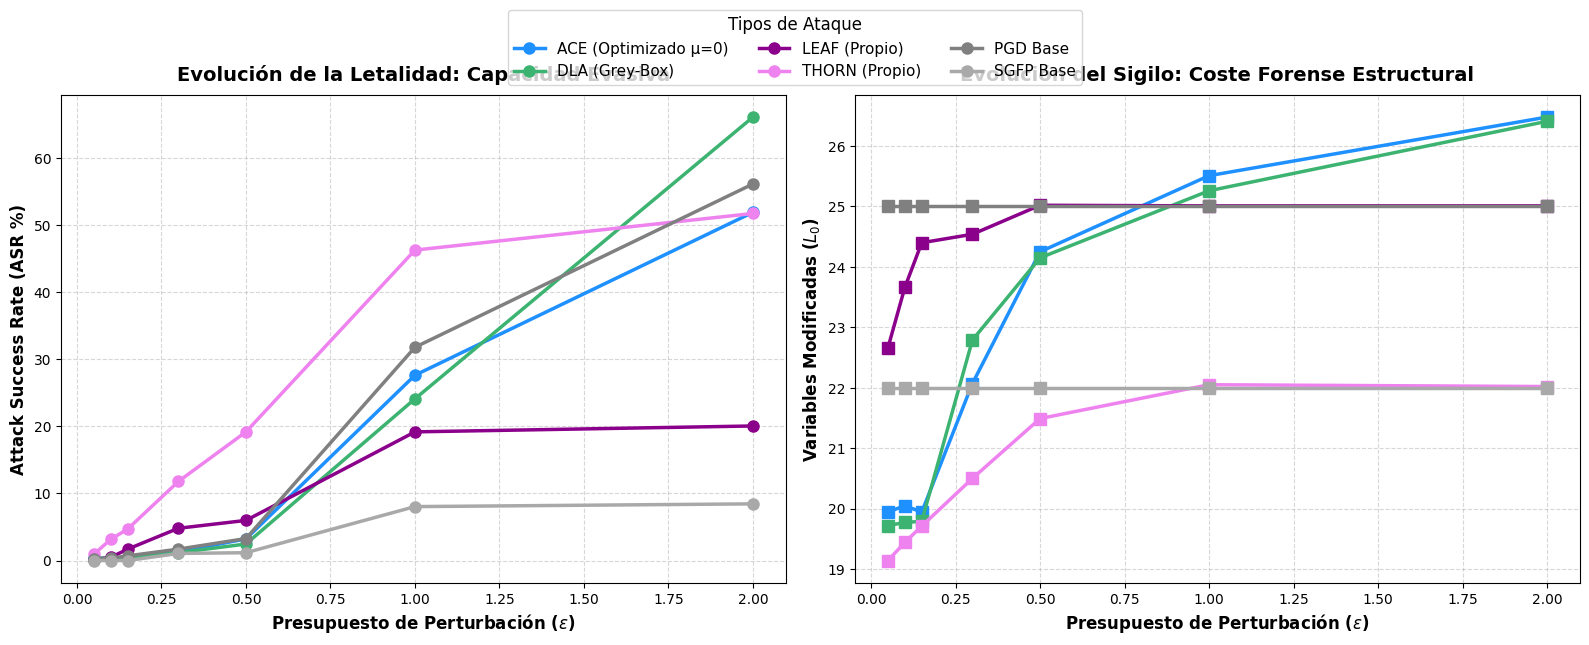

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
from pathlib import Path
from IPython.display import display, HTML

print("Análisis Desglosado: Letalidad vs Coste Forense")

OUTPUT_DIR = Path("outputs")
METRICS_DIR = OUTPUT_DIR / "metrics"

# 1. CARGA SEGURA DESDE EL DISCO DURO
try:
    df_resnet = joblib.load(METRICS_DIR / "historial_resnet_completo.pkl")
    df_trees  = joblib.load(METRICS_DIR / "historial_trees_completo.pkl")
    df_eval = pd.concat([df_resnet, df_trees], ignore_index=True)
except Exception as e:
    raise RuntimeError(f"[!] Error al cargar los datos. Asegúrate de ejecutar la celda de guardado primero. Detalle: {e}")

# 2. INYECCIÓN DE BASELINES BLINDADA
baselines_data = []
epsilons_unicos = df_eval['Epsilon'].unique()

try:
    col_l0 = 'L0 (Vars)' if 'L0 (Vars)' in df_ablacion.columns else ('L0' if 'L0' in df_ablacion.columns else None)
    col_l2 = 'L2 (Energía)' if 'L2 (Energía)' in df_ablacion.columns else ('L2' if 'L2' in df_ablacion.columns else None)

    for eps in epsilons_unicos:
        mask_pgd = (df_ablacion['Ataque'].str.contains('PGD')) & (df_ablacion['Epsilon'] == eps) & (df_ablacion['Escenario'].str.contains('ON'))
        if any(mask_pgd):
            baselines_data.append({"Epsilon": eps, "Ataque": "PGD Base", "ASR (%)": df_ablacion[mask_pgd]['ASR (%)'].values[0], "L0 (Vars)": df_ablacion[mask_pgd][col_l0].values[0] if col_l0 else 25.0, "L2 (Energía)": df_ablacion[mask_pgd][col_l2].values[0] if col_l2 else 10.0})

        mask_sgfp = (df_ablacion['Ataque'].str.contains('SGFP')) & (df_ablacion['Epsilon'] == eps) & (df_ablacion['Escenario'].str.contains('ON'))
        if any(mask_sgfp):
            baselines_data.append({"Epsilon": eps, "Ataque": "SGFP Base", "ASR (%)": df_ablacion[mask_sgfp]['ASR (%)'].values[0], "L0 (Vars)": df_ablacion[mask_sgfp][col_l0].values[0] if col_l0 else 22.0, "L2 (Energía)": df_ablacion[mask_sgfp][col_l2].values[0] if col_l2 else 2.0})

    df_baselines = pd.DataFrame(baselines_data)
    df_eval = pd.concat([df_eval, df_baselines], ignore_index=True)
except NameError:
    pass

# 3. CONFIGURACIÓN VISUAL DESGLOSADA (1 Fila, 2 Columnas)
df_eval['Ataque'] = df_eval['Ataque'].replace({'ACE (Propio)': 'ACE (Optimizado μ=0)', 'ACE (Optimizado)': 'ACE (Optimizado μ=0)'})

colores = {
    "PGD Base": "gray", "SGFP Base": "darkgray",
    "ACE (Optimizado μ=0)": "dodgerblue", "DLA (Grey-Box)": "mediumseagreen",
    "LEAF (Propio)": "darkmagenta", "THORN (Propio)": "violet"
}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
ataques_unicos = df_eval['Ataque'].unique()

# Panel 1: ASR vs Epsilon
for ataque in ataques_unicos:
    if ataque not in colores: continue
    df_ataque = df_eval[df_eval['Ataque'] == ataque].sort_values(by="Epsilon")
    if df_ataque.empty: continue

    axes[0].plot(df_ataque["Epsilon"], df_ataque["ASR (%)"],
                 color=colores[ataque], marker='o', linestyle='-', linewidth=2.5, markersize=8, label=ataque)

axes[0].set_title("Evolución de la Letalidad: Capacidad Evasiva", fontsize=14, fontweight='bold', pad=10)
axes[0].set_xlabel("Presupuesto de Perturbación ($\epsilon$)", fontsize=12, fontweight='bold')
axes[0].set_ylabel("Attack Success Rate (ASR %)", fontsize=12, fontweight='bold')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Panel 2: L0 vs Epsilon
for ataque in ataques_unicos:
    if ataque not in colores: continue
    df_ataque = df_eval[df_eval['Ataque'] == ataque].sort_values(by="Epsilon")
    if df_ataque.empty: continue

    # Usamos un marcador diferente (cuadrado) para distinguirlo del panel izquierdo
    axes[1].plot(df_ataque["Epsilon"], df_ataque["L0 (Vars)"],
                 color=colores[ataque], marker='s', linestyle='-', linewidth=2.5, markersize=8, label=ataque)

axes[1].set_title("Evolución del Sigilo: Coste Forense Estructural", fontsize=14, fontweight='bold', pad=10)
axes[1].set_xlabel("Presupuesto de Perturbación ($\epsilon$)", fontsize=12, fontweight='bold')
axes[1].set_ylabel("Variables Modificadas ($L_0$)", fontsize=12, fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.5)

# Leyenda unificada y centrada en la parte superior
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=3, title="Tipos de Ataque", fontsize=11, title_fontsize=12)

plt.tight_layout()
plt.show()

Nota: No hemos guardado el sigilo de los ataques del estudio de ablación, SGFP y PGD.